# Error Analysis and Physical Diagnostics

This notebook investigates the main failure modes of the final classical
Random Forest modulation classifier.

The objective is not to tune the model, but to understand its errors from
both a statistical and communications perspective.

Main questions:

1. Why does AM-SSB behave as an attractor at very low SNR?
2. Why do QPSK/8PSK remain confused?
3. Why do QAM16/QAM64 remain confused?
4. Why do WBFM/AM-DSB remain confused?
5. Which properties of the current feature representation explain these errors?
6. Which additional physically motivated features would be justified?

The test split remains untouched throughout this notebook.

## 1. Setup

Import the libraries required for the diagnostic analysis and define
the paths to the cached features and the previously trained model.

No model training is performed in this notebook.

In [122]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
)

In [123]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

MODEL_PATH = (
    MODELS_DIR
    / "random_forest_full_features.joblib"
)

## 2. Load cached validation features

The 28 handcrafted features were already computed during the previous
evaluation stage and stored on disk.

They are loaded here directly to avoid recomputing the feature extraction
pipeline from the raw RadioML signals.

The validation table contains:

- 28 signal features;
- the modulation label;
- the SNR;
- the sample identifier.

In [3]:
validation_features_full = pd.read_pickle(
    PROCESSED_DIR
    / "validation_full_features.pkl"
)

print(
    "Validation features:",
    validation_features_full.shape
)

validation_features_full.head()

Validation features: (33000, 31)


,i_mean,i_std,q_mean,q_std,magnitude_std,magnitude_max,power_mean,rms,papr,phase_diff_mean,...,autocorr_lag4,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_flatness,spectral_peak_frequency,spectral_peak_ratio,sample_id,modulation,snr
0,0.000087,0.006858,-0.000847,0.005433,0.004029,0.018723,0.000077,0.008790,4.536854,0.071092,...,0.278806,0.021167,0.253127,0.883861,0.529786,0.039062,0.063469,163488,QAM64,-14
1,0.003861,0.005008,-0.003597,0.004917,0.004008,0.020115,0.000077,0.008781,5.248161,0.033313,...,0.354363,0.010990,0.245663,0.748268,0.369249,0.000000,0.258543,28582,AM-DSB,-4
2,0.001212,0.004082,-0.005910,0.005124,0.004275,0.020078,0.000079,0.008906,5.082640,-0.054299,...,0.482997,-0.014490,0.227500,0.738403,0.360708,0.000000,0.282021,28485,AM-DSB,-4
3,0.000009,0.005784,-0.001441,0.006431,0.003981,0.019149,0.000077,0.008768,4.769057,0.022721,...,0.046496,-0.012721,0.252391,0.905906,0.549096,0.117188,0.039308,201977,WBFM,-18
4,-0.000147,0.003227,-0.001797,0.007913,0.003905,0.016861,0.000076,0.008734,3.726669,0.023644,...,0.404812,-0.003451,0.141141,0.736790,0.234692,0.054688,0.118674,70214,BPSK,0


## 3. Separate features and metadata

The classifier must receive exactly the same 28 feature columns used
during training.

Metadata columns (`sample_id`, `modulation`, and `snr`) are therefore
excluded from the feature matrix.

The SNR is retained only for posterior diagnostic analysis and is not
used as an input feature by the classifier.

In [4]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr",
]

feature_columns = [
    column
    for column
    in validation_features_full.columns
    if column not in metadata_columns
]

X_validation = validation_features_full[
    feature_columns
]

y_validation = validation_features_full[
    "modulation"
]

print(
    "X_validation:",
    X_validation.shape
)

print(
    "y_validation:",
    y_validation.shape
)

print(
    "Number of features:",
    len(feature_columns)
)

X_validation: (33000, 28)
y_validation: (33000,)
Number of features: 28


## 4. Load the selected Random Forest

The Random Forest selected in the previous stages is loaded from disk.

The model was trained using the complete training split and the 28-feature
representation. It is not retrained here because this notebook is intended
exclusively for error analysis.

In [5]:
final_candidate_rf = joblib.load(
    MODEL_PATH
)

print(
    "Model loaded:",
    type(final_candidate_rf).__name__
)

print(
    "Classes:",
    final_candidate_rf.classes_
)

Model loaded: RandomForestClassifier
Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


## 5. Reproduce the reference validation performance

Before performing any diagnostic analysis, the reference validation
metrics are reproduced.

This sanity check verifies that:

- the correct model has been loaded;
- the feature ordering is identical to the training configuration;
- the correct validation dataset is being used.

The expected reference results are approximately:

- Accuracy: 0.5314
- Macro-F1: 0.5493

In [6]:
validation_predictions = (
    final_candidate_rf.predict(
        X_validation
    )
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
)

print(
    f"Validation accuracy: "
    f"{validation_accuracy:.4f}"
)

print(
    f"Validation macro-F1: "
    f"{validation_f1:.4f}"
)

Validation accuracy: 0.5314
Validation macro-F1: 0.5493


## 6. Build the diagnostic dataframe

A compact dataframe is constructed containing, for every validation sample:

- the true modulation;
- the predicted modulation;
- the SNR.

This table will be the basis for the subsequent error analysis.
It allows predictions to be conditioned jointly on modulation class and
signal-to-noise ratio.

In [7]:
evaluation_df = pd.DataFrame({
    "true_modulation":
        y_validation.to_numpy(),

    "predicted_modulation":
        validation_predictions,

    "snr":
        validation_features_full[
            "snr"
        ].to_numpy(),
})

evaluation_df.head()

,true_modulation,predicted_modulation,snr
0,QAM64,BPSK,-14
1,AM-DSB,AM-DSB,-4
2,AM-DSB,AM-DSB,-4
3,WBFM,WBFM,-18
4,BPSK,PAM4,0


In [8]:
print(
    "Evaluation rows:",
    len(evaluation_df)
)

print(
    "SNR levels:",
    sorted(
        evaluation_df["snr"].unique()
    )
)

print(
    "Modulations:",
    sorted(
        evaluation_df[
            "true_modulation"
        ].unique()
    )
)

Evaluation rows: 33000
SNR levels: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


### Dataset consistency check

The diagnostic dataframe contains all **33,000 validation samples**,
covering:

- 11 modulation classes;
- 20 SNR levels from -20 to 18 dB in 2 dB increments.

The validation set is therefore complete and ready for conditional
error analysis.

### 7.1 Prediction probabilities

The Random Forest produces a class-probability vector for each validation
sample.

These probabilities are used here as diagnostic quantities rather than
as perfectly calibrated posterior probabilities.

The objective is to determine whether low-SNR predictions classified as
AM-SSB correspond to:

- confident predictions strongly favouring AM-SSB, or
- highly ambiguous predictions where AM-SSB only marginally receives
  the largest probability.

In [9]:
validation_probabilities = (
    final_candidate_rf.predict_proba(
        X_validation
    )
)

model_classes = final_candidate_rf.classes_

print(
    "Probability matrix shape:",
    validation_probabilities.shape
)

print(
    "Class order:",
    model_classes
)

print(
    "First probability sum:",
    validation_probabilities[0].sum()
)

Probability matrix shape: (33000, 11)
Class order: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
First probability sum: 1.0


### 7.2 Prediction uncertainty metrics

Three complementary uncertainty indicators are computed for every
validation sample.

**Maximum probability**

\[
p_{\max} = \max_c P(c|x)
\]

Higher values indicate that one class dominates the Random Forest vote.

**Top-2 margin**

\[
m = p_{(1)} - p_{(2)}
\]

where \(p_{(1)}\) and \(p_{(2)}\) are the largest and second-largest
predicted probabilities.

A small margin indicates ambiguity between the two most likely classes.

**Normalized entropy**

\[
H =
-\frac{\sum_c p_c \log(p_c)}
{\log(C)}
\]

where \(C=11\) is the number of modulation classes.

Values close to 0 indicate concentrated predictions, while values close
to 1 indicate highly uncertain predictions.

In [10]:
sorted_probabilities = np.sort(
    validation_probabilities,
    axis=1
)

max_probability = (
    sorted_probabilities[:, -1]
)

second_probability = (
    sorted_probabilities[:, -2]
)

top2_margin = (
    max_probability
    - second_probability
)

probability_entropy = -np.sum(
    validation_probabilities
    * np.log(
        validation_probabilities + 1e-12
    ),
    axis=1
)

normalized_entropy = (
    probability_entropy
    / np.log(len(model_classes))
)

In [11]:
evaluation_diagnostic_df = (
    evaluation_df.copy()
)

evaluation_diagnostic_df[
    "max_probability"
] = max_probability

evaluation_diagnostic_df[
    "top2_margin"
] = top2_margin

evaluation_diagnostic_df[
    "probability_entropy"
] = normalized_entropy

evaluation_diagnostic_df.head()

,true_modulation,predicted_modulation,snr,max_probability,top2_margin,probability_entropy
0,QAM64,BPSK,-14,0.201381,0.042865,0.869986
1,AM-DSB,AM-DSB,-4,0.688273,0.404658,0.303721
2,AM-DSB,AM-DSB,-4,0.506559,0.086265,0.413383
3,WBFM,WBFM,-18,0.159425,0.003493,0.973691
4,BPSK,PAM4,0,0.711774,0.453638,0.302207


In [12]:
evaluation_diagnostic_df[
    [
        "max_probability",
        "top2_margin",
        "probability_entropy"
    ]
].describe()

,max_probability,top2_margin,probability_entropy
count,33000.000000,33000.000000,3.300000e+04
mean,0.494483,0.314723,5.710059e-01
std,0.281885,0.330237,3.526067e-01
min,0.105116,0.000012,-4.170695e-13
25%,0.255858,0.084002,2.828249e-01
50%,0.425261,0.174538,5.925187e-01
75%,0.693233,0.445199,9.274906e-01
max,1.000000,1.000000,9.971807e-01


### 7.3 Predicted-class distribution across SNR

The validation set is balanced across modulation classes.

Therefore, if the classifier produced a roughly balanced set of predictions,
each predicted class would account for approximately

\[
\frac{1}{11} \approx 0.091
\]

of the samples at each SNR.

A strong increase in the fraction predicted as AM-SSB at low SNR would
provide direct evidence that AM-SSB behaves as an attractor in the current
feature space.

In [13]:
prediction_distribution = (
    evaluation_diagnostic_df
    .groupby(
        [
            "snr",
            "predicted_modulation"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

prediction_distribution_normalized = (
    prediction_distribution
    .div(
        prediction_distribution.sum(axis=1),
        axis=0
    )
)

prediction_distribution_normalized.round(3)

predicted_modulation,8PSK,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM16,QAM64,QPSK,WBFM
snr,,,,,,,,,,,
-20,0.004,0.024,0.930,0.007,0.001,0.002,0.002,0.004,0.002,0.013,0.012
-18,0.001,0.026,0.936,0.007,0.002,0.005,0.004,0.001,0.001,0.007,0.009
-16,0.005,0.023,0.922,0.009,0.004,0.005,0.005,0.002,0.002,0.013,0.009
-14,0.013,0.035,0.845,0.020,0.011,0.011,0.008,0.005,0.013,0.030,0.010
-12,0.013,0.057,0.761,0.013,0.019,0.016,0.011,0.021,0.026,0.033,0.031
-10,0.028,0.083,0.597,0.022,0.024,0.024,0.027,0.044,0.049,0.048,0.053
-8,0.030,0.090,0.414,0.041,0.031,0.059,0.055,0.051,0.084,0.050,0.095
-6,0.039,0.113,0.198,0.044,0.051,0.105,0.095,0.085,0.118,0.072,0.081
-4,0.039,0.123,0.095,0.048,0.084,0.101,0.118,0.116,0.130,0.084,0.061


### 7.4 AM-SSB prediction rate vs SNR

The fraction of all validation samples classified as AM-SSB is now
examined as a function of SNR.

Because the validation set contains the same number of samples from each
modulation, a balanced prediction distribution would assign approximately
\(1/11\) of the samples to AM-SSB.

Values substantially above this reference indicate an asymmetric
decision bias toward AM-SSB.

In [14]:
am_ssb_prediction_rate = (
    prediction_distribution_normalized[
        "AM-SSB"
    ]
)

am_ssb_prediction_rate.round(3)

snr
-20    0.930
-18    0.936
-16    0.922
-14    0.845
-12    0.761
-10    0.597
-8     0.414
-6     0.198
-4     0.095
-2     0.091
 0     0.091
 2     0.093
 4     0.085
 6     0.094
 8     0.087
 10    0.086
 12    0.090
 14    0.094
 16    0.092
 18    0.090
Name: AM-SSB, dtype: float64

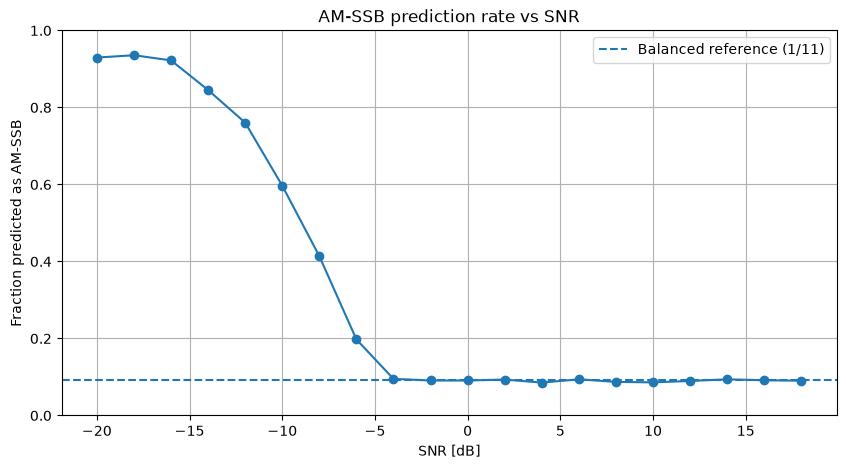

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    am_ssb_prediction_rate.index,
    am_ssb_prediction_rate.values,
    marker="o"
)

ax.axhline(
    1 / len(model_classes),
    linestyle="--",
    label="Balanced reference (1/11)"
)

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    "Fraction predicted as AM-SSB"
)

ax.set_title(
    "AM-SSB prediction rate vs SNR"
)

ax.set_ylim(0, 1)

ax.grid(True)

ax.legend()

plt.show()

### 7.5 Origin of AM-SSB predictions

The previous analysis quantifies how often AM-SSB is predicted.

The next step is to determine which true modulation classes contribute
to these predictions.

The analysis is first performed at -10 dB, where the confusion matrices
show strong migration of several digital modulation classes toward AM-SSB.

In [16]:
snr_to_inspect = -10

am_ssb_predictions = (
    evaluation_diagnostic_df[
        (
            evaluation_diagnostic_df["snr"]
            == snr_to_inspect
        )
        &
        (
            evaluation_diagnostic_df[
                "predicted_modulation"
            ]
            == "AM-SSB"
        )
    ]
    .copy()
)

print(
    "Samples predicted as AM-SSB:",
    len(am_ssb_predictions)
)

Samples predicted as AM-SSB: 985


In [17]:
true_class_counts = (
    am_ssb_predictions[
        "true_modulation"
    ]
    .value_counts()
)

true_class_distribution = (
    am_ssb_predictions[
        "true_modulation"
    ]
    .value_counts(
        normalize=True
    )
)

am_ssb_origin_df = pd.DataFrame({
    "count": true_class_counts,
    "fraction":
        true_class_distribution
})

am_ssb_origin_df

,count,fraction
true_modulation,,
AM-SSB,144,0.146193
CPFSK,136,0.138071
8PSK,135,0.137056
BPSK,133,0.135025
QPSK,128,0.129949
GFSK,127,0.128934
PAM4,65,0.065990
WBFM,61,0.061929
AM-DSB,47,0.047716


In [18]:
am_ssb_confusion_rate = (
    evaluation_diagnostic_df[
        evaluation_diagnostic_df["snr"]
        == snr_to_inspect
    ]
    .groupby("true_modulation")
    ["predicted_modulation"]
    .apply(
        lambda predictions:
        np.mean(
            predictions == "AM-SSB"
        )
    )
    .sort_values(
        ascending=False
    )
)

am_ssb_confusion_rate.round(3)

true_modulation
AM-SSB    0.960
CPFSK     0.907
8PSK      0.900
BPSK      0.887
QPSK      0.853
GFSK      0.847
PAM4      0.433
WBFM      0.407
AM-DSB    0.313
QAM16     0.053
QAM64     0.007
Name: predicted_modulation, dtype: float64

### Preliminary observation

AM-SSB exhibits a strong low-SNR attractor behaviour.

The fraction of validation samples predicted as AM-SSB increases from
approximately the balanced reference value of 9.1% at moderate and high
SNR to more than 90% below -16 dB.

The effect disappears progressively as SNR increases:

- -20 dB: 93.0%
- -16 dB: 92.2%
- -10 dB: 59.7%
- -6 dB: 19.8%
- -4 dB: 9.5%
- 0 dB: 9.1%

Therefore, the AM-SSB bias is not a general class imbalance of the
classifier. It is specifically associated with the low-SNR regime.

### 7.6 Confidence of correct and incorrect AM-SSB predictions

The strong AM-SSB prediction bias does not by itself reveal whether the
Random Forest is confident in these decisions.

Two possible mechanisms are considered:

1. **Uncertainty-driven attractor**

   At low SNR the modulation-specific information disappears, several
   classes obtain similar probabilities, and AM-SSB only marginally
   becomes the most likely class.

2. **Feature-space attraction**

   Noise-degraded samples systematically occupy a region of the current
   feature space that the Random Forest has learned with relatively high
   confidence as AM-SSB.

To distinguish these mechanisms, correct AM-SSB predictions are compared
with false AM-SSB predictions using maximum probability, top-2 margin,
and normalized probability entropy.

In [19]:
am_ssb_predictions[
    "correct_am_ssb"
] = (
    am_ssb_predictions[
        "true_modulation"
    ]
    == "AM-SSB"
)

In [20]:
am_ssb_confidence_comparison = (
    am_ssb_predictions
    .groupby("correct_am_ssb")
    [
        [
            "max_probability",
            "top2_margin",
            "probability_entropy"
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
)

am_ssb_confidence_comparison.round(3)

max_probability               top2_margin                \
                          mean median    std        mean median    std   
correct_am_ssb                                                           
False                    0.239  0.241  0.049       0.129  0.133  0.060   
True                     0.265  0.270  0.043       0.161  0.172  0.054   

               probability_entropy                
                              mean median    std  
correct_am_ssb                                    
False                        0.943  0.942  0.023  
True                         0.932  0.930  0.022

In [21]:
snr_levels_to_compare = [
    -20,
    -16,
    -12,
    -10,
    -8,
    -6,
    -4,
    0,
]

In [22]:
am_ssb_confidence_rows = []

for snr in snr_levels_to_compare:

    subset = evaluation_diagnostic_df[
        (
            evaluation_diagnostic_df["snr"]
            == snr
        )
        &
        (
            evaluation_diagnostic_df[
                "predicted_modulation"
            ]
            == "AM-SSB"
        )
    ].copy()

    subset["correct_am_ssb"] = (
        subset["true_modulation"]
        == "AM-SSB"
    )

    for correct_value, group in (
        subset.groupby("correct_am_ssb")
    ):

        am_ssb_confidence_rows.append({
            "snr": snr,

            "prediction_type": (
                "Correct AM-SSB"
                if correct_value
                else "False AM-SSB"
            ),

            "n_samples": len(group),

            "mean_max_probability":
                group[
                    "max_probability"
                ].mean(),

            "median_max_probability":
                group[
                    "max_probability"
                ].median(),

            "mean_top2_margin":
                group[
                    "top2_margin"
                ].mean(),

            "mean_entropy":
                group[
                    "probability_entropy"
                ].mean(),
        })

am_ssb_confidence_by_snr = (
    pd.DataFrame(
        am_ssb_confidence_rows
    )
)

am_ssb_confidence_by_snr.round(3)   

,snr,prediction_type,n_samples,mean_max_probability,median_max_probability,mean_top2_margin,mean_entropy
0,-20,False AM-SSB,1391,0.259,0.262,0.154,0.934
1,-20,Correct AM-SSB,143,0.262,0.268,0.159,0.934
2,-16,False AM-SSB,1382,0.259,0.265,0.155,0.934
3,-16,Correct AM-SSB,140,0.257,0.262,0.152,0.936
4,-12,False AM-SSB,1116,0.248,0.253,0.140,0.939
5,-12,Correct AM-SSB,139,0.259,0.268,0.154,0.934
6,-10,False AM-SSB,841,0.239,0.241,0.129,0.943
7,-10,Correct AM-SSB,144,0.265,0.270,0.161,0.932
8,-8,False AM-SSB,540,0.225,0.226,0.115,0.950
9,-8,Correct AM-SSB,143,0.259,0.260,0.154,0.935


In [23]:
false_am_ssb_confidence = (
    am_ssb_confidence_by_snr[
        am_ssb_confidence_by_snr[
            "prediction_type"
        ]
        == "False AM-SSB"
    ]
    .set_index("snr")
)

false_am_ssb_confidence.round(3)

,prediction_type,n_samples,mean_max_probability,median_max_probability,mean_top2_margin,mean_entropy
snr,,,,,,
-20,False AM-SSB,1391,0.259,0.262,0.154,0.934
-16,False AM-SSB,1382,0.259,0.265,0.155,0.934
-12,False AM-SSB,1116,0.248,0.253,0.140,0.939
-10,False AM-SSB,841,0.239,0.241,0.129,0.943
-8,False AM-SSB,540,0.225,0.226,0.115,0.950
-6,False AM-SSB,183,0.193,0.182,0.076,0.962
-4,False AM-SSB,18,0.234,0.225,0.126,0.946
0,False AM-SSB,8,0.274,0.278,0.176,0.930


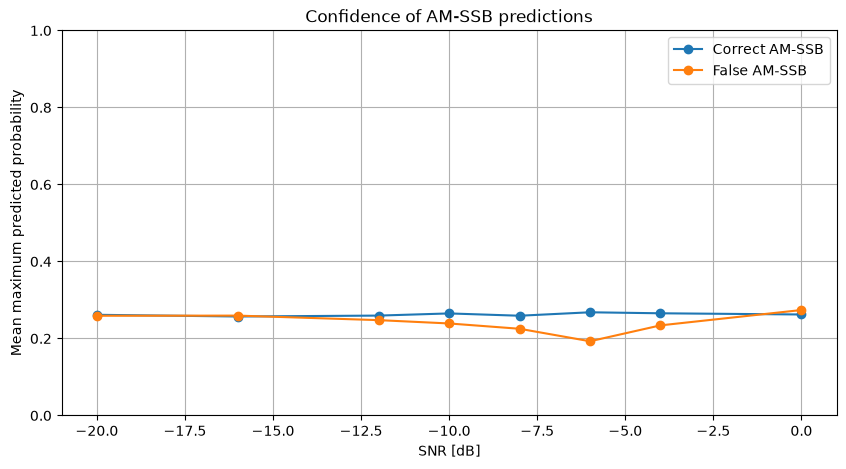

In [24]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for prediction_type in [
    "Correct AM-SSB",
    "False AM-SSB",
]:

    subset = (
        am_ssb_confidence_by_snr[
            am_ssb_confidence_by_snr[
                "prediction_type"
            ]
            == prediction_type
        ]
    )

    ax.plot(
        subset["snr"],
        subset[
            "mean_max_probability"
        ],
        marker="o",
        label=prediction_type,
    )

ax.set_xlabel("SNR [dB]")
ax.set_ylabel(
    "Mean maximum predicted probability"
)

ax.set_title(
    "Confidence of AM-SSB predictions"
)

ax.set_ylim(0, 1)

ax.grid(True)
ax.legend()

plt.show()

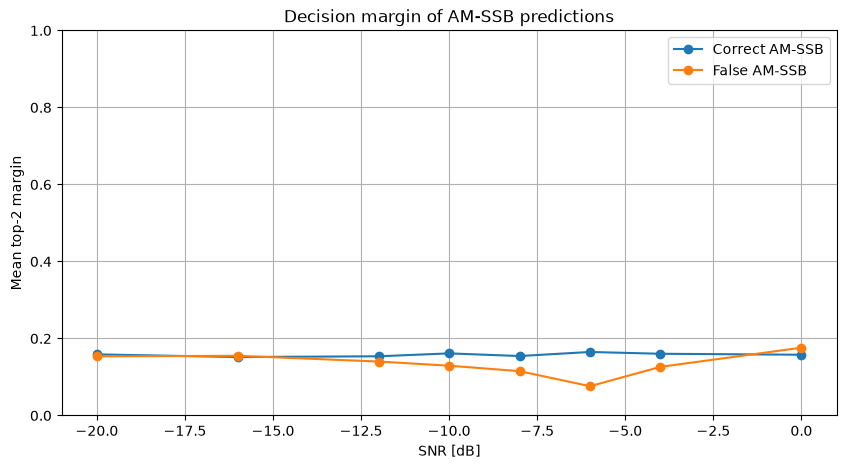

In [25]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for prediction_type in [
    "Correct AM-SSB",
    "False AM-SSB",
]:

    subset = (
        am_ssb_confidence_by_snr[
            am_ssb_confidence_by_snr[
                "prediction_type"
            ]
            == prediction_type
        ]
    )

    ax.plot(
        subset["snr"],
        subset[
            "mean_top2_margin"
        ],
        marker="o",
        label=prediction_type,
    )

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Mean top-2 margin")

ax.set_title(
    "Decision margin of AM-SSB predictions"
)

ax.set_ylim(0, 1)

ax.grid(True)
ax.legend()

plt.show()

In [26]:
sorted_class_indices = np.argsort(
    validation_probabilities,
    axis=1
)

second_class_indices = (
    sorted_class_indices[:, -2]
)

second_predicted_class = (
    model_classes[
        second_class_indices
    ]
)

evaluation_diagnostic_df[
    "second_predicted_modulation"
] = second_predicted_class

In [27]:
false_am_ssb_minus10 = (
    evaluation_diagnostic_df[
        (
            evaluation_diagnostic_df["snr"]
            == -10
        )
        &
        (
            evaluation_diagnostic_df[
                "predicted_modulation"
            ]
            == "AM-SSB"
        )
        &
        (
            evaluation_diagnostic_df[
                "true_modulation"
            ]
            != "AM-SSB"
        )
    ]
)

second_choice_distribution = (
    false_am_ssb_minus10[
        "second_predicted_modulation"
    ]
    .value_counts(
        normalize=True
    )
)

second_choice_distribution.round(3)

second_predicted_modulation
8PSK      0.258
BPSK      0.185
QPSK      0.156
CPFSK     0.115
GFSK      0.099
AM-DSB    0.096
WBFM      0.076
PAM4      0.012
QAM16     0.002
Name: proportion, dtype: float64

In [28]:
second_choice_by_true_class = (
    pd.crosstab(
        false_am_ssb_minus10[
            "true_modulation"
        ],
        false_am_ssb_minus10[
            "second_predicted_modulation"
        ],
        normalize="index",
    )
)

second_choice_by_true_class.round(2)

second_predicted_modulation,8PSK,AM-DSB,BPSK,CPFSK,GFSK,PAM4,QAM16,QPSK,WBFM
true_modulation,,,,,,,,,
8PSK,0.35,0.07,0.15,0.16,0.07,0.01,0.00,0.15,0.04
AM-DSB,0.13,0.21,0.13,0.02,0.19,0.00,0.00,0.06,0.26
BPSK,0.29,0.08,0.23,0.14,0.05,0.02,0.00,0.16,0.05
CPFSK,0.24,0.06,0.19,0.12,0.12,0.01,0.01,0.18,0.07
GFSK,0.27,0.10,0.17,0.12,0.13,0.00,0.01,0.15,0.06
PAM4,0.23,0.02,0.31,0.15,0.06,0.06,0.00,0.14,0.03
QAM16,0.38,0.12,0.25,0.00,0.00,0.00,0.00,0.12,0.12
QAM64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
QPSK,0.27,0.12,0.20,0.08,0.05,0.00,0.00,0.22,0.05


### 7.7 Conclusions

The low-SNR AM-SSB attractor is confirmed.

At extremely low SNR (-20 to -16 dB), more than 90% of all validation
samples are predicted as AM-SSB. Correct and incorrect AM-SSB predictions
show almost identical confidence statistics, with maximum probabilities
around 0.26 and normalized entropy around 0.93.

This indicates that AM-SSB is not genuinely recognizable in this regime.
Instead, many modulation classes appear to collapse toward a common region
of the current feature space that the Random Forest preferentially assigns
to AM-SSB.

The classifier remains globally uncertain: the winning AM-SSB probability
is only about 0.25, while probability mass remains broadly distributed
across the remaining classes. Nevertheless, AM-SSB receives a systematic
advantage over every individual alternative.

Between approximately -10 and -6 dB, the behaviour changes. Correct AM-SSB
predictions become noticeably more confident than false AM-SSB predictions,
while the number of false AM-SSB classifications decreases sharply. This
suggests the recovery of modulation-specific information in the feature
representation.

The second-choice analysis also shows that the original modulation is not
consistently recovered as the runner-up class. Therefore, the effect cannot
be explained simply as AM-SSB narrowly beating the correct class. However,
some family-level structure remains visible, particularly among PSK
modulations.

The next experiment will investigate which current features collapse
across classes at low SNR and which retain modulation-dependent structure.

---

# Part II — Feature-space degradation

## 8. Feature distributions across SNR

The previous analysis showed that many modulation classes converge toward
an AM-SSB-dominated decision region at very low SNR.

The objective of this section is to investigate whether this behaviour can
be observed directly in the current feature representation.

We will examine how class-conditional feature distributions evolve as SNR
decreases and identify:

1. features whose between-class differences collapse under noise;
2. features that preserve modulation-dependent information;
3. features that may explain the unusual AM-SSB decision region.

In [29]:
features_to_inspect = [
    "phase_diff_std",
    "i_std",
    "q_std",
    "magnitude_std",
    "papr",
    "autocorr_lag1",
    "spectral_entropy",
    "spectral_flatness",
]

### 8.1 Representative features

A reduced set of representative features is analysed first.

The selected variables cover complementary signal properties:

- `phase_diff_std`: temporal phase variation;
- `i_std`, `q_std`: I/Q dispersion;
- `magnitude_std`: envelope variability;
- `papr`: peak-to-average behaviour;
- `autocorr_lag1`: short-term temporal dependence;
- `spectral_entropy`: spectral concentration/disorder;
- `spectral_flatness`: noise-like versus structured spectrum.

Highly redundant features are initially excluded to simplify interpretation.

In [30]:
features_to_inspect = [
    "phase_diff_std",
    "i_std",
    "q_std",
    "magnitude_std",
    "papr",
    "autocorr_lag1",
    "spectral_entropy",
    "spectral_flatness",
]

feature_summary = (
    validation_features_full
    .groupby(
        ["snr", "modulation"]
    )[features_to_inspect]
    .mean()
)

feature_summary.head()

phase_diff_std     i_std     q_std  magnitude_std      papr  \
snr modulation                                                                
-20 8PSK              1.780991  0.006194  0.006248       0.004142  5.759309   
    AM-DSB            1.770598  0.006161  0.006259       0.004123  5.611459   
    AM-SSB            1.785338  0.006158  0.006268       0.004115  6.096745   
    BPSK              1.777264  0.006161  0.006271       0.004141  5.715361   
    CPFSK             1.790282  0.006159  0.006263       0.004112  5.720677   

                autocorr_lag1  spectral_entropy  spectral_flatness  
snr modulation                                                      
-20 8PSK             0.083911          0.912701           0.561500  
    AM-DSB           0.091186          0.914581           0.568675  
    AM-SSB           0.081559          0.914316           0.567261  
    BPSK             0.089054          0.912711           0.562607  
    CPFSK            0.081226          0.914122           0.567456

In [31]:
feature_class_spread_rows = []

for snr in sorted(
    validation_features_full["snr"].unique()
):

    subset = (
        validation_features_full[
            validation_features_full["snr"]
            == snr
        ]
    )

    class_means = (
        subset
        .groupby("modulation")[
            features_to_inspect
        ]
        .mean()
    )

    for feature in features_to_inspect:

        feature_class_spread_rows.append({
            "snr": snr,
            "feature": feature,
            "class_mean_spread": (
                class_means[feature].max()
                - class_means[feature].min()
            ),
        })

feature_class_spread_df = pd.DataFrame(
    feature_class_spread_rows
)

feature_class_spread_df.head()

,snr,feature,class_mean_spread
0,-20,phase_diff_std,0.019683
1,-20,i_std,0.000071
2,-20,q_std,0.000088
3,-20,magnitude_std,0.000052
4,-20,papr,0.485286


### 8.3 Scale-independent class separability

The absolute spread between class means cannot be compared directly
across features because the variables have different numerical scales.

A scale-independent effect-size measure is therefore computed for each
feature and SNR.

For a given feature, eta squared is defined as

\[
\eta^2 =
\frac{SS_{\mathrm{between}}}
     {SS_{\mathrm{total}}}
\]

where \(SS_{\mathrm{between}}\) measures the variability of class means
around the global mean and \(SS_{\mathrm{total}}\) measures the total
sample variability.

Interpretation:

- \(\eta^2 \approx 0\): modulation class explains almost none of the
  feature variability;
- larger \(\eta^2\): the feature contains stronger class-dependent
  information.

The measure is used descriptively rather than as a formal statistical
significance test.

In [32]:
def eta_squared_by_class(
    dataframe,
    feature,
    class_column="modulation",
):
    values = dataframe[feature].to_numpy()

    overall_mean = np.mean(values)

    ss_total = np.sum(
        (values - overall_mean) ** 2
    )

    ss_between = 0.0

    for _, group in dataframe.groupby(
        class_column
    ):
        group_values = (
            group[feature].to_numpy()
        )

        group_mean = np.mean(
            group_values
        )

        ss_between += (
            len(group_values)
            * (group_mean - overall_mean) ** 2
        )

    return (
        ss_between
        / (ss_total + 1e-12)
    )

In [33]:
separability_rows = []

for snr in sorted(
    validation_features_full[
        "snr"
    ].unique()
):

    subset = (
        validation_features_full[
            validation_features_full["snr"]
            == snr
        ]
    )

    for feature in features_to_inspect:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        separability_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

feature_separability_df = pd.DataFrame(
    separability_rows
)

feature_separability_df.head(16)

,snr,feature,eta_squared
0,-20,phase_diff_std,0.004626
1,-20,i_std,0.004028
2,-20,q_std,0.005640
3,-20,magnitude_std,0.002635
4,-20,papr,0.008881
5,-20,autocorr_lag1,0.005526
6,-20,spectral_entropy,0.006165
7,-20,spectral_flatness,0.006774
8,-18,phase_diff_std,0.013584
9,-18,i_std,0.003144


In [34]:
separability_matrix = (
    feature_separability_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

separability_matrix.round(3)

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
feature,,,,,,,,,,,,,,,,,,,,
autocorr_lag1,0.006,0.022,0.075,0.251,0.689,0.832,0.876,0.902,0.889,0.907,0.911,0.916,0.950,0.904,0.965,0.957,0.963,0.909,0.923,0.954
i_std,0.004,0.003,0.004,0.007,0.015,0.052,0.172,0.259,0.413,0.486,0.530,0.642,0.659,0.681,0.685,0.689,0.706,0.687,0.706,0.734
magnitude_std,0.003,0.009,0.004,0.005,0.031,0.093,0.237,0.400,0.444,0.485,0.728,0.752,0.900,0.876,0.832,0.912,0.839,0.788,0.928,0.856
papr,0.009,0.004,0.006,0.008,0.030,0.051,0.109,0.217,0.304,0.287,0.462,0.493,0.763,0.390,0.681,0.854,0.798,0.452,0.634,0.694
phase_diff_std,0.005,0.014,0.071,0.219,0.573,0.768,0.837,0.892,0.871,0.860,0.871,0.886,0.932,0.893,0.928,0.947,0.941,0.910,0.920,0.942
q_std,0.006,0.005,0.005,0.011,0.017,0.054,0.197,0.295,0.460,0.575,0.594,0.715,0.719,0.759,0.771,0.774,0.760,0.766,0.752,0.814
spectral_entropy,0.006,0.003,0.018,0.147,0.573,0.813,0.872,0.891,0.864,0.845,0.872,0.906,0.943,0.924,0.941,0.944,0.948,0.927,0.934,0.950
spectral_flatness,0.007,0.005,0.011,0.062,0.342,0.651,0.791,0.870,0.862,0.878,0.884,0.885,0.943,0.890,0.938,0.950,0.952,0.893,0.909,0.947


### 8.4 Feature separability across SNR

The evolution of \(\eta^2\) across SNR reveals when each handcrafted
feature begins to carry modulation-dependent information.

If the low-SNR feature-collapse hypothesis is correct, most features
should exhibit values close to zero at very low SNR and progressively
increase as the signal becomes stronger relative to the noise.

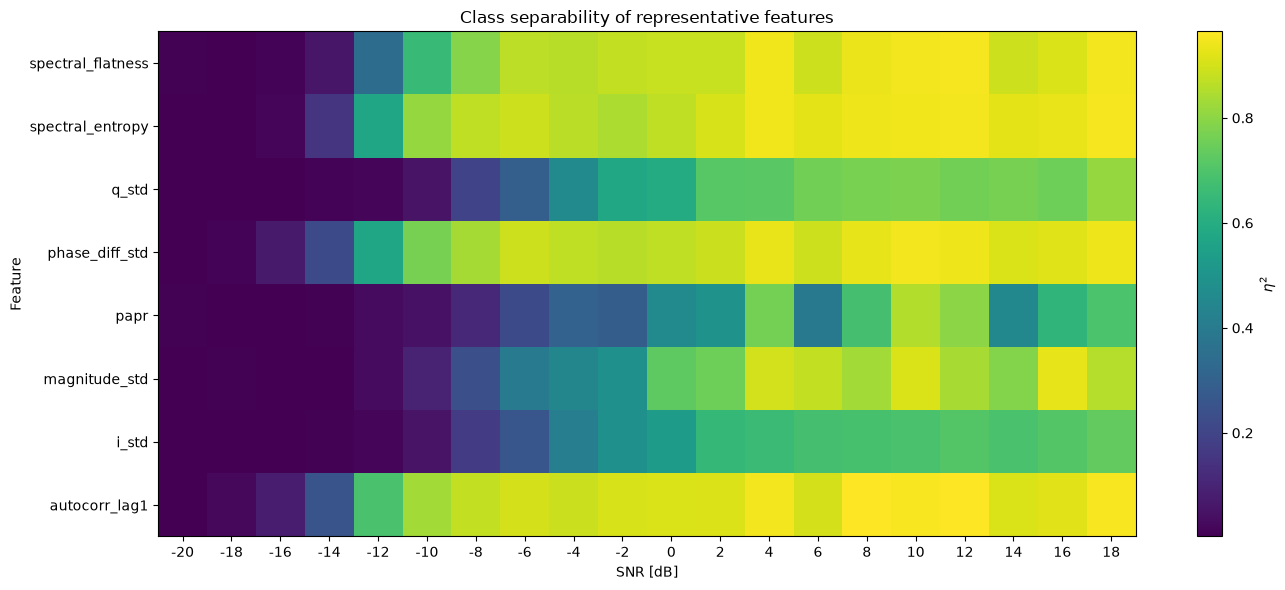

In [35]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

image = ax.imshow(
    separability_matrix.values,
    aspect="auto",
    origin="lower",
)

ax.set_xticks(
    np.arange(
        len(separability_matrix.columns)
    )
)

ax.set_xticklabels(
    separability_matrix.columns
)

ax.set_yticks(
    np.arange(
        len(separability_matrix.index)
    )
)

ax.set_yticklabels(
    separability_matrix.index
)

ax.set_xlabel("SNR [dB]")

ax.set_ylabel("Feature")

ax.set_title(
    "Class separability of representative features"
)

colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    r"$\eta^2$"
)

plt.tight_layout()
plt.show()

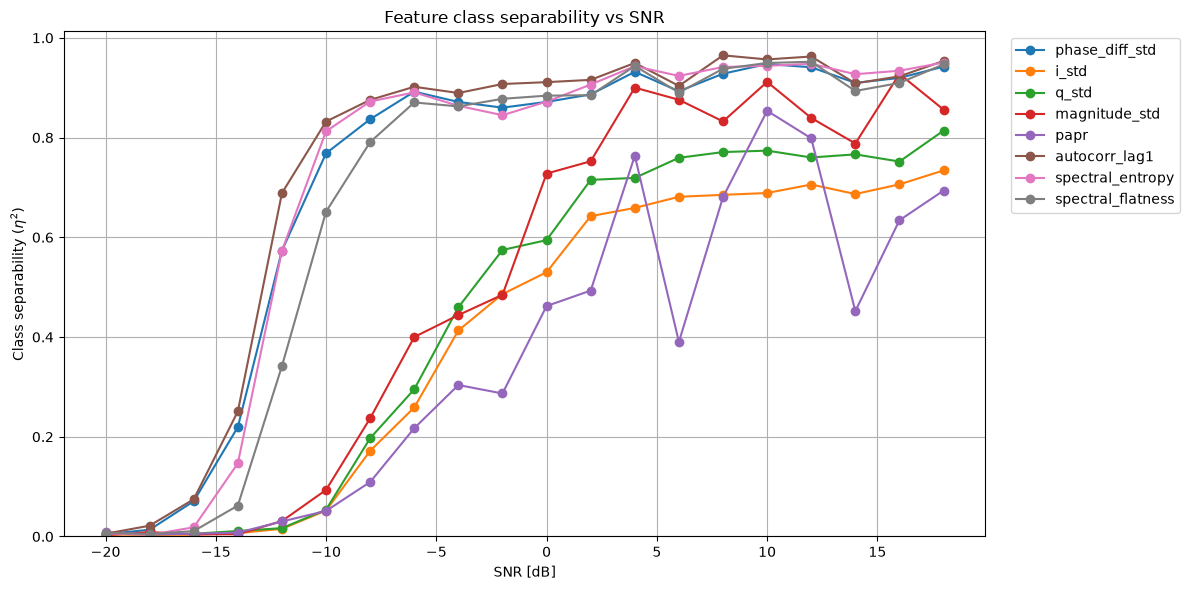

In [36]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for feature in features_to_inspect:

    feature_data = (
        feature_separability_df[
            feature_separability_df[
                "feature"
            ]
            == feature
        ]
    )

    ax.plot(
        feature_data["snr"],
        feature_data["eta_squared"],
        marker="o",
        label=feature,
    )

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    r"Class separability ($\eta^2$)"
)

ax.set_title(
    "Feature class separability vs SNR"
)

ax.set_ylim(
    bottom=0
)

ax.grid(True)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [37]:
selected_snr_levels = [
    -20,
    -10,
    0,
    18,
]

In [38]:
selected_separability = (
    separability_matrix[
        selected_snr_levels
    ]
    .copy()
)

selected_separability[
    "change_-20_to_18"
] = (
    selected_separability[18]
    - selected_separability[-20]
)

selected_separability.sort_values(
    "change_-20_to_18",
    ascending=False,
).round(3)

snr,-20,-10,0,18,change_-20_to_18
feature,,,,,
autocorr_lag1,0.006,0.832,0.911,0.954,0.948
spectral_entropy,0.006,0.813,0.872,0.950,0.944
spectral_flatness,0.007,0.651,0.884,0.947,0.940
phase_diff_std,0.005,0.768,0.871,0.942,0.938
magnitude_std,0.003,0.093,0.728,0.856,0.853
q_std,0.006,0.054,0.594,0.814,0.808
i_std,0.004,0.052,0.530,0.734,0.730
papr,0.009,0.051,0.462,0.694,0.685


### 8.5 Preliminary conclusions

The analysis confirms a strong SNR-dependent collapse of the current
feature representation.

At -20 dB, all representative features exhibit eta-squared values close
to zero, indicating that modulation identity explains almost none of
their variability. This is consistent with the previously observed
AM-SSB attractor behaviour.

A rapid recovery of class-dependent structure occurs approximately
between -14 and -8 dB. Temporal, phase and spectral descriptors recover
particularly early:

- normalized lag-1 autocorrelation,
- phase-difference standard deviation,
- spectral entropy,
- spectral flatness.

Amplitude-related descriptors such as I/Q dispersion and magnitude
variability recover more gradually.

The disappearance of the AM-SSB attractor therefore coincides with the
recovery of modulation-dependent structure in the feature space.

However, eta-squared measures global class separability. A high value
does not imply that every pair of modulation classes is distinguishable.
Persistent confusions such as QPSK/8PSK and QAM16/QAM64 may still occupy
very similar regions for these features.

Pair-specific analysis is therefore required before drawing conclusions
about the limitations of the current representation.

### 8.6 Separability of the complete feature representation

The previous analysis focused on eight representative descriptors.

The same eta-squared analysis is now extended to all 28 handcrafted
features in order to determine which components of the current
representation retain the strongest modulation-dependent information
at different SNR regimes.

This analysis is diagnostic only and is not used for feature selection.

In [39]:
all_feature_columns = [
    column
    for column in validation_features_full.columns
    if column not in [
        "sample_id",
        "modulation",
        "snr",
    ]
]

print(
    "Number of features:",
    len(all_feature_columns)
)

Number of features: 28


In [40]:
all_separability_rows = []

for snr in sorted(
    validation_features_full[
        "snr"
    ].unique()
):

    subset = validation_features_full[
        validation_features_full["snr"]
        == snr
    ]

    for feature in all_feature_columns:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        all_separability_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

all_feature_separability_df = pd.DataFrame(
    all_separability_rows
)

In [41]:
all_separability_matrix = (
    all_feature_separability_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

selected_all_features = (
    all_separability_matrix[
        [-20, -10, 0, 18]
    ]
    .copy()
)

selected_all_features[
    "change_-20_to_18"
] = (
    selected_all_features[18]
    - selected_all_features[-20]
)

selected_all_features.sort_values(
    18,
    ascending=False,
).round(3)

snr,-20,-10,0,18,change_-20_to_18
feature,,,,,
autocorr_lag1,0.006,0.832,0.911,0.954,0.948
autocorr_lag2,0.004,0.850,0.905,0.953,0.948
spectral_entropy,0.006,0.813,0.872,0.950,0.944
spectral_flatness,0.007,0.651,0.884,0.947,0.940
spectral_bandwidth,0.002,0.689,0.893,0.946,0.944
phase_diff_std,0.005,0.768,0.871,0.942,0.938
spectral_peak_ratio,0.009,0.668,0.877,0.920,0.911
autocorr_lag4,0.002,0.741,0.844,0.918,0.916
magnitude_std,0.003,0.093,0.728,0.856,0.853


In [42]:
all_separability_matrix[
    -20
].sort_values(
    ascending=False
).round(3)

feature
q_mean                     0.020
magnitude_kurtosis         0.010
spectral_peak_ratio        0.009
papr                       0.009
phase_diff_kurtosis        0.009
i_mean                     0.008
magnitude_max              0.007
spectral_flatness          0.007
spectral_peak_frequency    0.007
spectral_entropy           0.006
i_skew                     0.006
phase_diff_skew            0.006
magnitude_skew             0.006
q_std                      0.006
autocorr_lag1              0.006
q_kurtosis                 0.005
phase_diff_mean            0.005
phase_diff_std             0.005
autocorr_lag2              0.004
i_std                      0.004
spectral_centroid          0.004
magnitude_std              0.003
q_skew                     0.003
rms                        0.003
power_mean                 0.003
spectral_bandwidth         0.002
autocorr_lag4              0.002
i_kurtosis                 0.002
Name: -20, dtype: float64

In [43]:
all_separability_matrix[
    -10
].sort_values(
    ascending=False
).round(3)

feature
autocorr_lag2              0.850
autocorr_lag1              0.832
spectral_entropy           0.813
phase_diff_kurtosis        0.772
phase_diff_std             0.768
autocorr_lag4              0.741
spectral_bandwidth         0.689
spectral_peak_ratio        0.668
spectral_flatness          0.651
q_mean                     0.183
magnitude_std              0.093
rms                        0.089
power_mean                 0.088
magnitude_skew             0.071
magnitude_max              0.064
q_std                      0.054
i_std                      0.052
papr                       0.051
i_kurtosis                 0.039
q_kurtosis                 0.038
magnitude_kurtosis         0.032
spectral_peak_frequency    0.014
phase_diff_skew            0.010
i_mean                     0.007
phase_diff_mean            0.007
spectral_centroid          0.007
q_skew                     0.006
i_skew                     0.006
Name: -10, dtype: float64

In [44]:
all_separability_matrix[
    0
].sort_values(
    ascending=False
).round(3)

feature
autocorr_lag1              0.911
autocorr_lag2              0.905
spectral_bandwidth         0.893
spectral_flatness          0.884
spectral_peak_ratio        0.877
spectral_entropy           0.872
phase_diff_std             0.871
autocorr_lag4              0.844
rms                        0.736
power_mean                 0.735
magnitude_std              0.728
phase_diff_kurtosis        0.646
q_std                      0.594
i_std                      0.530
magnitude_max              0.522
papr                       0.462
q_mean                     0.379
magnitude_skew             0.372
q_kurtosis                 0.302
magnitude_kurtosis         0.299
i_kurtosis                 0.275
phase_diff_mean            0.181
i_mean                     0.066
spectral_centroid          0.065
phase_diff_skew            0.019
spectral_peak_frequency    0.011
q_skew                     0.011
i_skew                     0.006
Name: 0, dtype: float64

In [45]:
all_separability_matrix[
    18
].sort_values(
    ascending=False
).round(3)

feature
autocorr_lag1              0.954
autocorr_lag2              0.953
spectral_entropy           0.950
spectral_flatness          0.947
spectral_bandwidth         0.946
phase_diff_std             0.942
spectral_peak_ratio        0.920
autocorr_lag4              0.918
magnitude_std              0.856
q_std                      0.814
i_std                      0.734
papr                       0.694
magnitude_max              0.687
magnitude_skew             0.641
phase_diff_kurtosis        0.597
rms                        0.518
phase_diff_mean            0.512
q_mean                     0.510
magnitude_kurtosis         0.484
phase_diff_skew            0.404
power_mean                 0.353
q_kurtosis                 0.238
i_kurtosis                 0.214
i_mean                     0.083
spectral_centroid          0.068
spectral_peak_frequency    0.024
q_skew                     0.013
i_skew                     0.004
Name: 18, dtype: float64

### 8.7 Conclusions of the global feature analysis

The complete 28-feature representation confirms the low-SNR feature-collapse
hypothesis.

At -20 dB, none of the handcrafted descriptors exhibits meaningful global
class separability. As SNR increases, modulation-dependent structure first
reappears predominantly in temporal, phase and spectral descriptors.

At -10 dB, the strongest globally discriminative features are:

- normalized autocorrelations;
- spectral entropy;
- phase-difference statistics;
- spectral bandwidth;
- spectral peak ratio;
- spectral flatness.

Amplitude-related descriptors such as I/Q dispersion and magnitude
variability recover more gradually and become substantially more
discriminative at medium and high SNR.

Some descriptors, including spectral peak frequency, spectral centroid and
I/Q skewness, remain weak global discriminators even at high SNR.

The results support the interpretation that the low-SNR AM-SSB attractor
coincides with a collapse of modulation-dependent structure in the current
feature space.

However, the high eta-squared values observed at moderate and high SNR
describe global separation across all eleven classes. They do not imply
that specific modulation pairs are separable.

The next analysis therefore focuses on the persistent structural
confusions individually.

---

# Part III — Persistent structural confusions

## 9. QPSK vs 8PSK

QPSK and 8PSK remain mutually confused even at high SNR.

This is physically plausible because both modulations belong to the
M-PSK family and share several important properties:

- approximately constant-envelope signalling;
- similar pulse shaping;
- similar occupied bandwidth;
- similar spectral characteristics.

Their fundamental difference is the discrete phase alphabet.

QPSK uses four phase states, whereas 8PSK uses eight.

Therefore, features describing general spectral shape, envelope
variability or overall phase dispersion may distinguish PSK from other
families without necessarily distinguishing QPSK from 8PSK.

The objective of this section is to determine whether the current
28-feature representation contains sufficient pair-specific information
to separate these two modulations.

### 9.1 Pairwise feature separability

Eta-squared is recomputed using only QPSK and 8PSK samples.

This removes the influence of the remaining nine modulation classes and
answers a more specific question:

> How much of the variability of each current feature can be explained
> specifically by the distinction between QPSK and 8PSK?

A feature may show strong global class separability while providing almost
no information for this particular pair.

In [46]:
psk_pair = [
    "QPSK",
    "8PSK",
]

psk_pair_separability_rows = []

for snr in sorted(
    validation_features_full[
        "snr"
    ].unique()
):

    subset = validation_features_full[
        (
            validation_features_full[
                "snr"
            ]
            == snr
        )
        &
        (
            validation_features_full[
                "modulation"
            ].isin(psk_pair)
        )
    ]

    for feature in all_feature_columns:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        psk_pair_separability_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

psk_pair_separability_df = pd.DataFrame(
    psk_pair_separability_rows
)

In [47]:
psk_pair_separability_matrix = (
    psk_pair_separability_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

psk_pair_separability_matrix[
    [-20, -10, 0, 10, 18]
].sort_values(
    18,
    ascending=False,
).round(3)

snr,-20,-10,0,10,18
feature,,,,,
phase_diff_skew,0.000,0.001,0.002,0.062,0.049
phase_diff_kurtosis,0.003,0.060,0.009,0.035,0.034
magnitude_kurtosis,0.002,0.000,0.000,0.033,0.031
phase_diff_mean,0.001,0.001,0.012,0.014,0.028
magnitude_skew,0.001,0.000,0.015,0.016,0.019
i_mean,0.001,0.001,0.003,0.001,0.013
i_kurtosis,0.002,0.000,0.039,0.031,0.012
spectral_centroid,0.000,0.003,0.009,0.013,0.010
phase_diff_std,0.000,0.026,0.018,0.006,0.009


In [48]:
psk_pair_separability_matrix[
    18
].sort_values(
    ascending=False
).round(3)

feature
phase_diff_skew            0.049
phase_diff_kurtosis        0.034
magnitude_kurtosis         0.031
phase_diff_mean            0.028
magnitude_skew             0.019
i_mean                     0.013
i_kurtosis                 0.012
spectral_centroid          0.010
phase_diff_std             0.009
spectral_peak_frequency    0.008
q_kurtosis                 0.004
spectral_peak_ratio        0.004
i_skew                     0.003
q_std                      0.001
spectral_bandwidth         0.001
power_mean                 0.001
q_mean                     0.001
spectral_flatness          0.001
autocorr_lag1              0.001
autocorr_lag2              0.001
spectral_entropy           0.000
rms                        0.000
autocorr_lag4              0.000
magnitude_std              0.000
papr                       0.000
i_std                      0.000
magnitude_max              0.000
q_skew                     0.000
Name: 18, dtype: float64

In [49]:
psk_pair_separability_matrix[
    0
].sort_values(
    ascending=False
).round(3)

feature
spectral_bandwidth         0.040
i_kurtosis                 0.039
spectral_flatness          0.030
autocorr_lag1              0.028
autocorr_lag2              0.027
spectral_entropy           0.018
phase_diff_std             0.018
power_mean                 0.015
rms                        0.015
magnitude_skew             0.015
magnitude_std              0.015
phase_diff_mean            0.012
phase_diff_kurtosis        0.009
spectral_centroid          0.009
magnitude_max              0.006
spectral_peak_frequency    0.006
q_std                      0.005
papr                       0.004
q_skew                     0.004
i_mean                     0.003
autocorr_lag4              0.003
spectral_peak_ratio        0.003
q_mean                     0.002
q_kurtosis                 0.002
phase_diff_skew            0.002
i_skew                     0.001
i_std                      0.001
magnitude_kurtosis         0.000
Name: 0, dtype: float64

In [50]:
high_snr_levels = [
    8,
    10,
    12,
    14,
    16,
    18,
]

psk_high_snr_mean = (
    psk_pair_separability_matrix[
        high_snr_levels
    ]
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
)

top_psk_features = (
    psk_high_snr_mean
    .head(8)
    .index
    .tolist()
)

top_psk_features

['phase_diff_skew',
 'phase_diff_mean',
 'magnitude_kurtosis',
 'phase_diff_kurtosis',
 'magnitude_skew',
 'i_kurtosis',
 'q_kurtosis',
 'phase_diff_std']

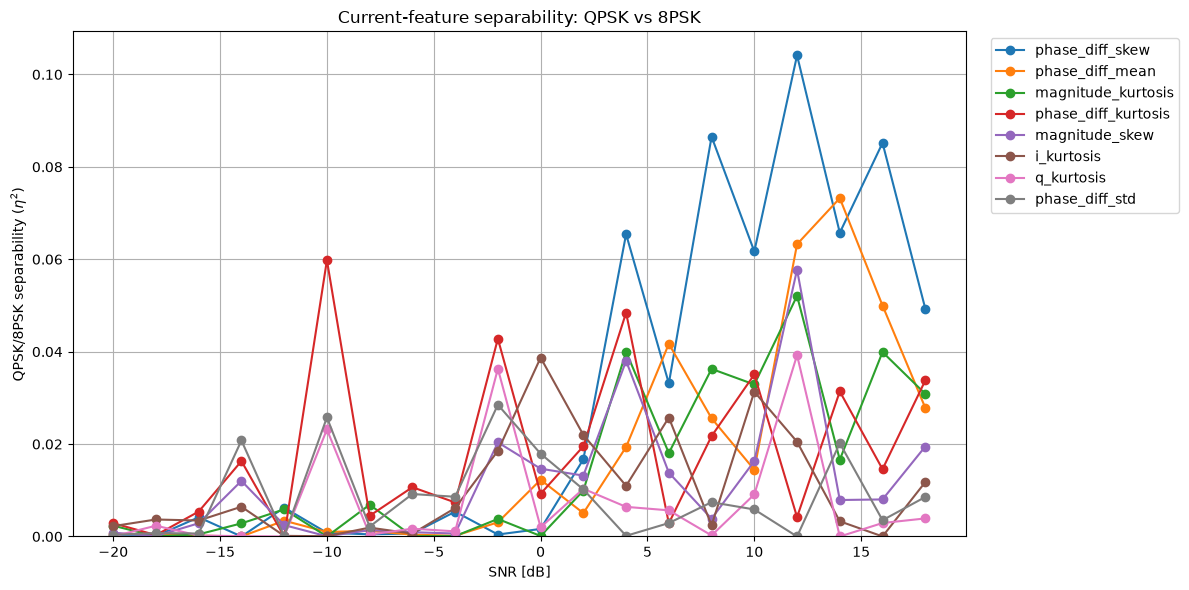

In [51]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for feature in top_psk_features:

    feature_data = (
        psk_pair_separability_df[
            psk_pair_separability_df[
                "feature"
            ]
            == feature
        ]
    )

    ax.plot(
        feature_data["snr"],
        feature_data["eta_squared"],
        marker="o",
        label=feature,
    )

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    r"QPSK/8PSK separability ($\eta^2$)"
)

ax.set_title(
    "Current-feature separability: QPSK vs 8PSK"
)

ax.set_ylim(bottom=0)

ax.grid(True)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

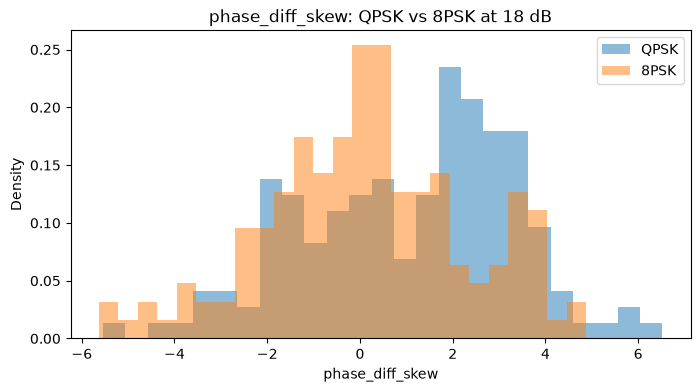

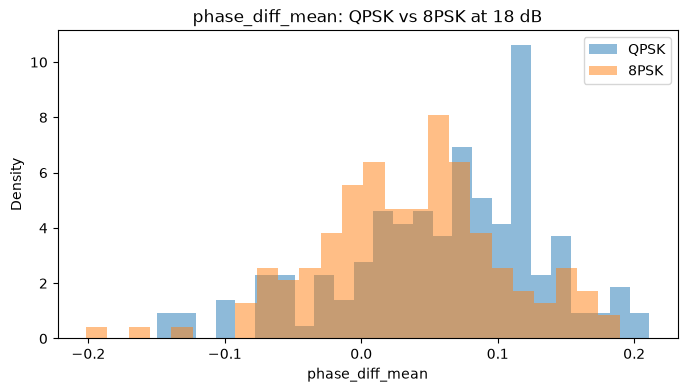

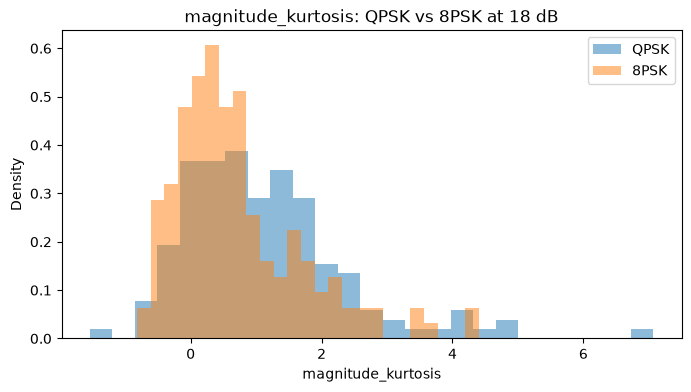

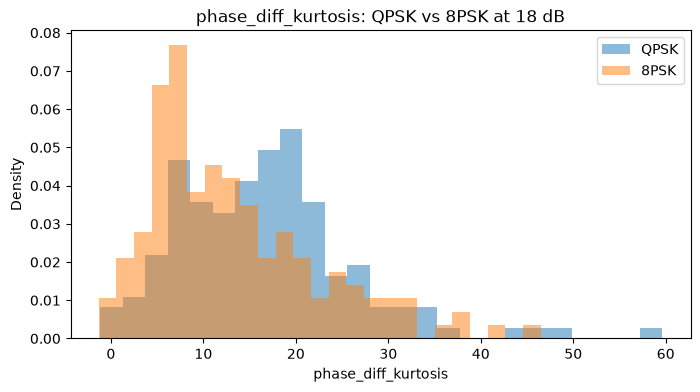

In [52]:
features_for_distribution = (
    top_psk_features[:4]
)

snr_to_plot = 18

for feature in features_for_distribution:

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    for modulation in psk_pair:

        values = (
            validation_features_full[
                (
                    validation_features_full[
                        "snr"
                    ]
                    == snr_to_plot
                )
                &
                (
                    validation_features_full[
                        "modulation"
                    ]
                    == modulation
                )
            ][feature]
        )

        ax.hist(
            values,
            bins=25,
            density=True,
            alpha=0.5,
            label=modulation,
        )

    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    ax.set_title(
        f"{feature}: QPSK vs 8PSK "
        f"at {snr_to_plot} dB"
    )

    ax.legend()

    plt.show()

### 9.5 Conclusions — QPSK vs 8PSK

The current handcrafted representation provides very little
pair-specific information for distinguishing QPSK from 8PSK.

Even at 18 dB, the strongest individual feature,
`phase_diff_skew`, reaches only approximately eta-squared = 0.05.
Most temporal, amplitude and spectral descriptors exhibit substantially
smaller values.

This contrasts strongly with the global feature analysis. For example,
`phase_diff_std` reaches eta-squared ≈ 0.94 across all eleven modulation
classes at 18 dB, but only ≈ 0.01 when the analysis is restricted to
QPSK and 8PSK.

Therefore, the current representation is effective at identifying broad
modulation structure but does not adequately represent the distinction
between different PSK orders.

The observed feature distributions show extensive overlap even at high
SNR. Spectral descriptors are particularly uninformative for this pair,
which is physically consistent with QPSK and 8PSK sharing similar pulse
shaping and spectral characteristics.

Their fundamental distinction lies in the discrete angular symmetry of
the constellation. The results therefore motivate the later evaluation
of circular phase moments and M-PSK-specific descriptors such as fourth-
and eighth-order angular moments.

## 10. QAM16 vs QAM64

QAM16 and QAM64 remain strongly confused even at high SNR.

Both modulations share the same general QAM structure and similar
spectral characteristics. Their main physical distinction is the number
and distribution of constellation points, particularly the radial and
amplitude structure of the I/Q samples.

The current representation contains several amplitude-related statistics,
including magnitude standard deviation, extrema, PAPR, skewness and
kurtosis.

This section investigates whether these descriptors contain sufficient
pair-specific information to distinguish QAM16 from QAM64.

In [53]:
qam_pair = [
    "QAM16",
    "QAM64",
]

qam_pair_separability_rows = []

for snr in sorted(
    validation_features_full[
        "snr"
    ].unique()
):

    subset = validation_features_full[
        (
            validation_features_full[
                "snr"
            ]
            == snr
        )
        &
        (
            validation_features_full[
                "modulation"
            ].isin(qam_pair)
        )
    ]

    for feature in all_feature_columns:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        qam_pair_separability_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

qam_pair_separability_df = pd.DataFrame(
    qam_pair_separability_rows
)

In [54]:
qam_pair_separability_matrix = (
    qam_pair_separability_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

qam_pair_separability_matrix[
    [-20, -10, 0, 10, 18]
].sort_values(
    18,
    ascending=False,
).round(3)

snr,-20,-10,0,10,18
feature,,,,,
magnitude_skew,0.001,0.186,0.010,0.064,0.025
spectral_centroid,0.000,0.009,0.001,0.000,0.009
phase_diff_kurtosis,0.003,0.614,0.102,0.000,0.009
spectral_peak_frequency,0.003,0.007,0.000,0.000,0.008
q_skew,0.000,0.007,0.004,0.000,0.007
autocorr_lag1,0.000,0.739,0.025,0.002,0.005
phase_diff_mean,0.000,0.024,0.002,0.001,0.005
phase_diff_std,0.008,0.672,0.064,0.005,0.004
spectral_entropy,0.008,0.713,0.042,0.016,0.004


In [55]:
qam_pair_separability_matrix[
    18
].sort_values(
    ascending=False
).round(3)

feature
magnitude_skew             0.025
spectral_centroid          0.009
phase_diff_kurtosis        0.009
spectral_peak_frequency    0.008
q_skew                     0.007
autocorr_lag1              0.005
phase_diff_mean            0.005
phase_diff_std             0.004
spectral_entropy           0.004
magnitude_std              0.003
spectral_peak_ratio        0.003
q_std                      0.003
autocorr_lag2              0.003
i_skew                     0.003
q_mean                     0.002
magnitude_kurtosis         0.001
magnitude_max              0.001
papr                       0.001
i_std                      0.001
spectral_flatness          0.001
i_mean                     0.001
spectral_bandwidth         0.001
autocorr_lag4              0.001
phase_diff_skew            0.000
rms                        0.000
q_kurtosis                 0.000
power_mean                 0.000
i_kurtosis                 0.000
Name: 18, dtype: float64

In [56]:
qam_pair_separability_matrix[
    0
].sort_values(
    ascending=False
).round(3)

feature
spectral_bandwidth         0.179
phase_diff_kurtosis        0.102
spectral_flatness          0.083
phase_diff_std             0.064
spectral_entropy           0.042
autocorr_lag1              0.025
autocorr_lag2              0.022
phase_diff_skew            0.010
magnitude_skew             0.010
q_mean                     0.009
autocorr_lag4              0.007
i_mean                     0.005
q_skew                     0.004
q_kurtosis                 0.002
magnitude_std              0.002
power_mean                 0.002
rms                        0.002
phase_diff_mean            0.002
spectral_centroid          0.001
i_std                      0.001
magnitude_kurtosis         0.001
magnitude_max              0.001
papr                       0.001
i_kurtosis                 0.000
q_std                      0.000
spectral_peak_ratio        0.000
i_skew                     0.000
spectral_peak_frequency    0.000
Name: 0, dtype: float64

In [57]:
qam_high_snr_mean = (
    qam_pair_separability_matrix[
        [8, 10, 12, 14, 16, 18]
    ]
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
)

top_qam_features = (
    qam_high_snr_mean
    .head(8)
    .index
    .tolist()
)

top_qam_features

['magnitude_skew',
 'papr',
 'magnitude_max',
 'magnitude_std',
 'rms',
 'power_mean',
 'q_kurtosis',
 'i_kurtosis']

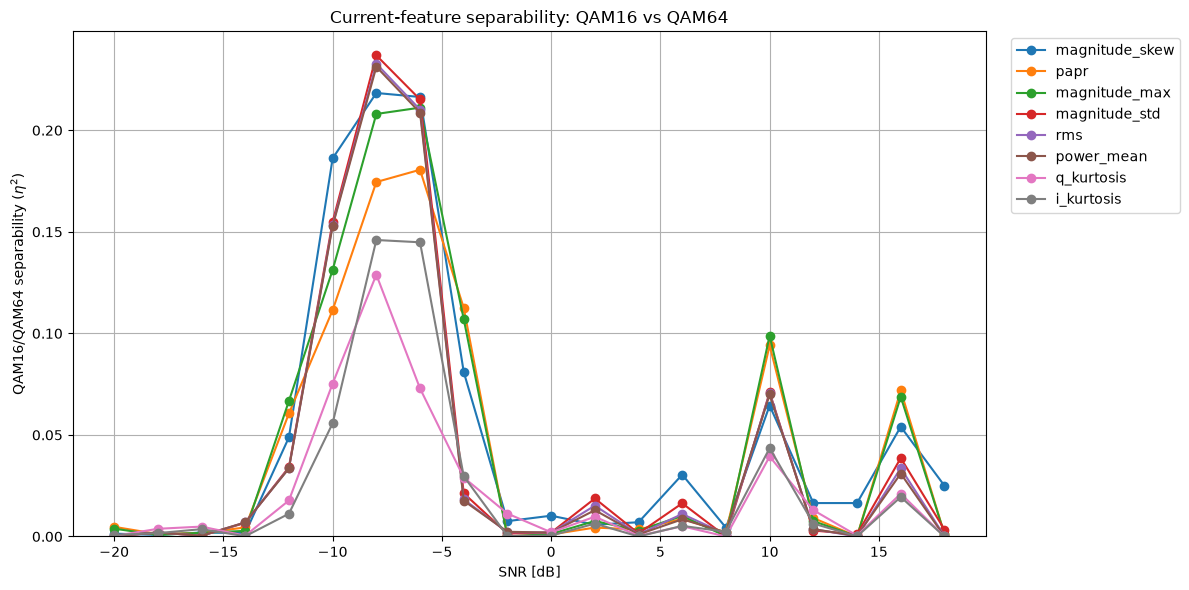

In [58]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for feature in top_qam_features:

    feature_data = (
        qam_pair_separability_df[
            qam_pair_separability_df[
                "feature"
            ]
            == feature
        ]
    )

    ax.plot(
        feature_data["snr"],
        feature_data["eta_squared"],
        marker="o",
        label=feature,
    )

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    r"QAM16/QAM64 separability ($\eta^2$)"
)

ax.set_title(
    "Current-feature separability: QAM16 vs QAM64"
)

ax.set_ylim(bottom=0)

ax.grid(True)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

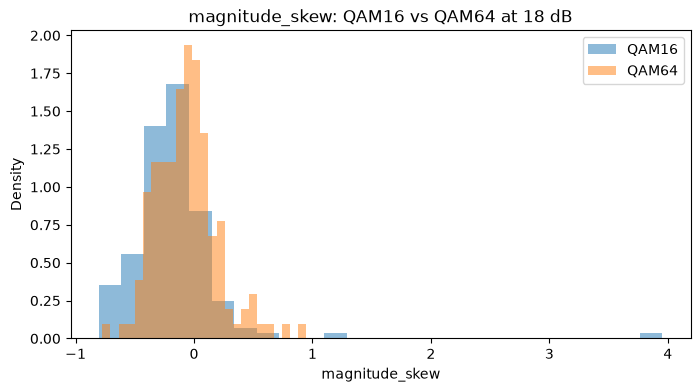

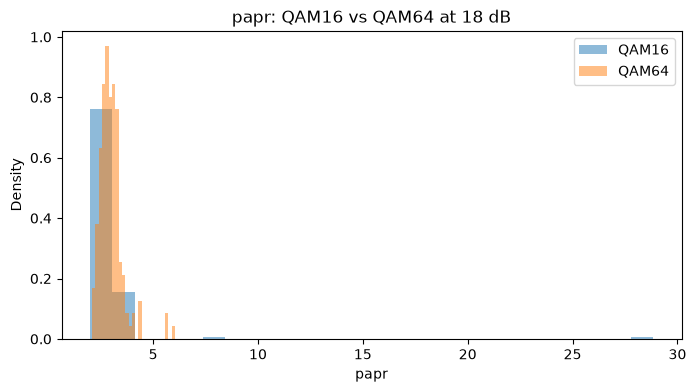

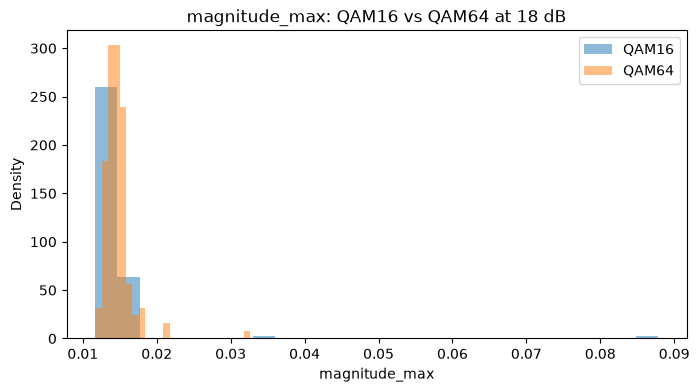

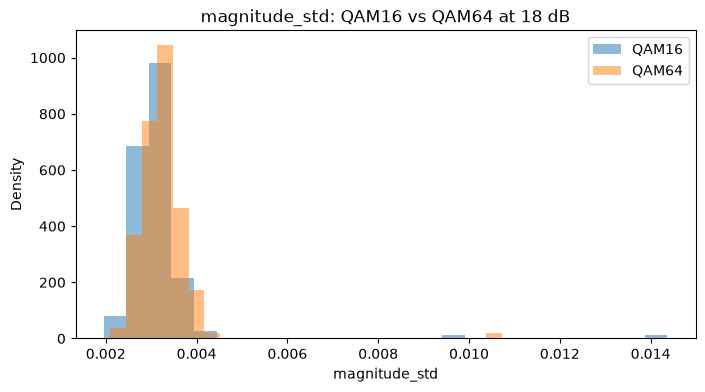

In [59]:
qam_features_for_distribution = (
    top_qam_features[:4]
)

snr_to_plot = 18

for feature in qam_features_for_distribution:

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    for modulation in qam_pair:

        values = (
            validation_features_full[
                (
                    validation_features_full[
                        "snr"
                    ]
                    == snr_to_plot
                )
                &
                (
                    validation_features_full[
                        "modulation"
                    ]
                    == modulation
                )
            ][feature]
        )

        ax.hist(
            values,
            bins=25,
            density=True,
            alpha=0.5,
            label=modulation,
        )

    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    ax.set_title(
        f"{feature}: QAM16 vs QAM64 "
        f"at {snr_to_plot} dB"
    )

    ax.legend()

    plt.show()

### 10.5 Preliminary conclusions — QAM16 vs QAM64

The current feature representation provides very weak pair-specific
separation between QAM16 and QAM64 at high SNR.

At 18 dB, the strongest individual descriptor reaches only approximately
eta-squared = 0.025, while most features are close to zero.

The amplitude-related distributions examined at high SNR show extensive
overlap. Statistics such as magnitude standard deviation, magnitude
maximum and PAPR therefore do not adequately describe the multi-level
radial structure that differentiates QAM16 from QAM64.

An unusual non-monotonic behaviour is also observed: several amplitude
features exhibit greater marginal QAM16/QAM64 separation around -10 to
-6 dB than at high SNR. This observation should not be interpreted as
QAM classification becoming intrinsically easier under noise. It may
result from the interaction between AWGN, per-window normalization,
finite 128-sample observations and the selected summary statistics.

The high-SNR results motivate later evaluation of richer radial
descriptors, including normalized amplitude moments, radial quantiles
and fourth-order cumulants.

However, because the global Random Forest exhibits a strongly asymmetric
confusion at high SNR, its decision probabilities should be examined
before concluding that the error is exclusively caused by insufficient
features.

### 10.6 QAM16/QAM64 decision asymmetry

The high-SNR confusion matrix is strongly asymmetric:

- approximately half of QAM16 samples are classified as QAM64;
- almost all QAM64 samples are correctly classified.

This section examines the Random Forest class probabilities to determine
whether QAM16 samples lie close to the QAM16/QAM64 decision boundary or
whether the classifier systematically assigns them substantially greater
support for QAM64.

Random Forest probabilities are used as relative confidence indicators
and are not assumed to be perfectly calibrated posterior probabilities.

In [62]:
qam16_index = np.where(
    model_classes == "QAM16"
)[0][0]

qam64_index = np.where(
    model_classes == "QAM64"
)[0][0]

print(
    "QAM16 probability index:",
    qam16_index
)

print(
    "QAM64 probability index:",
    qam64_index
)

QAM16 probability index: 7
QAM64 probability index: 8


In [63]:
evaluation_diagnostic_df[
    "prob_qam16"
] = validation_probabilities[
    :, qam16_index
]

evaluation_diagnostic_df[
    "prob_qam64"
] = validation_probabilities[
    :, qam64_index
]

evaluation_diagnostic_df[
    "qam_probability_difference"
] = (
    evaluation_diagnostic_df[
        "prob_qam64"
    ]
    -
    evaluation_diagnostic_df[
        "prob_qam16"
    ]
)

In [64]:
qam_18 = (
    evaluation_diagnostic_df[
        (
            evaluation_diagnostic_df["snr"]
            == 18
        )
        &
        (
            evaluation_diagnostic_df[
                "true_modulation"
            ].isin(
                ["QAM16", "QAM64"]
            )
        )
    ]
    .copy()
)

qam_18.groupby(
    "true_modulation"
)[
    [
        "prob_qam16",
        "prob_qam64",
        "qam_probability_difference",
        "max_probability",
        "top2_margin",
    ]
].agg(
    ["mean", "median", "std"]
).round(3)

prob_qam16               prob_qam64                \
                      mean median    std       mean median    std   
true_modulation                                                     
QAM16                0.461  0.472  0.147      0.475  0.441  0.146   
QAM64                0.101  0.085  0.065      0.866  0.911  0.138   

                qam_probability_difference               max_probability  \
                                      mean median    std            mean   
true_modulation                                                            
QAM16                                0.014 -0.010  0.272           0.570   
QAM64                                0.765  0.825  0.190           0.867   

                              top2_margin                
                median    std        mean median    std  
true_modulation                                          
QAM16            0.560  0.118       0.201  0.158  0.181  
QAM64            0.911  0.135       0.763  0.825  0.195

In [65]:
qam16_18 = (
    qam_18[
        qam_18[
            "true_modulation"
        ]
        == "QAM16"
    ]
    .copy()
)

qam16_18[
    "qam16_correct"
] = (
    qam16_18[
        "predicted_modulation"
    ]
    == "QAM16"
)

qam16_confidence_comparison = (
    qam16_18
    .groupby("qam16_correct")
    [
        [
            "prob_qam16",
            "prob_qam64",
            "qam_probability_difference",
            "max_probability",
            "top2_margin",
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
)

qam16_confidence_comparison.round(3)

prob_qam16               prob_qam64                \
                    mean median    std       mean median    std   
qam16_correct                                                     
False              0.350  0.380  0.115      0.579  0.546  0.143   
True               0.561  0.572  0.089      0.381  0.379  0.061   

              qam_probability_difference               max_probability         \
                                    mean median    std            mean median   
qam16_correct                                                                   
False                              0.229  0.139  0.227           0.579  0.546   
True                              -0.180 -0.165  0.122           0.561  0.572   

                     top2_margin                
                 std        mean median    std  
qam16_correct                                   
False          0.143       0.224  0.138  0.229  
True           0.089       0.180  0.165  0.122

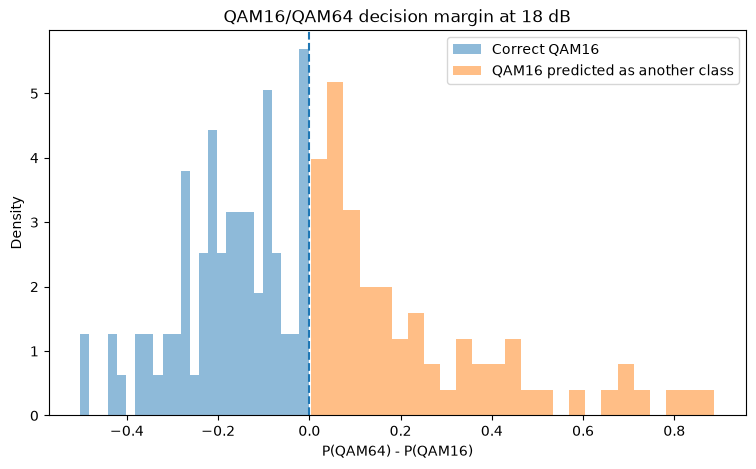

In [66]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for correct_value, label in [
    (True, "Correct QAM16"),
    (False, "QAM16 predicted as another class"),
]:

    values = qam16_18[
        qam16_18[
            "qam16_correct"
        ]
        == correct_value
    ][
        "qam_probability_difference"
    ]

    ax.hist(
        values,
        bins=25,
        density=True,
        alpha=0.5,
        label=label,
    )

ax.axvline(
    0,
    linestyle="--"
)

ax.set_xlabel(
    "P(QAM64) - P(QAM16)"
)

ax.set_ylabel("Density")

ax.set_title(
    "QAM16/QAM64 decision margin at 18 dB"
)

ax.legend()

plt.show()

In [67]:
qam16_18[
    "predicted_modulation"
].value_counts(
    normalize=True
).round(3)

predicted_modulation
QAM16    0.527
QAM64    0.467
8PSK     0.007
Name: proportion, dtype: float64

In [68]:
evaluation_diagnostic_df[
    "prob_qam16"
] = validation_probabilities[
    :, qam16_index
]

evaluation_diagnostic_df[
    "prob_qam64"
] = validation_probabilities[
    :, qam64_index
]

evaluation_diagnostic_df[
    "qam_probability_difference"
] = (
    evaluation_diagnostic_df[
        "prob_qam64"
    ]
    -
    evaluation_diagnostic_df[
        "prob_qam16"
    ]
)

### 10.11 Conclusions — QAM16/QAM64 decision behaviour

The probability analysis confirms that the QAM16/QAM64 confusion is
highly localized within the QAM family.

At 18 dB, QAM64 is recognized with very high confidence. Its mean
predicted probability for QAM64 is approximately 0.87, while the mean
QAM16 probability is only approximately 0.10.

QAM16 behaves very differently. Across all true QAM16 samples, the mean
probabilities assigned to QAM16 and QAM64 are approximately equal,
placing the class close to the QAM16/QAM64 decision boundary.

Correctly classified QAM16 samples tend to satisfy

\[
P(QAM16) > P(QAM64),
\]

whereas misclassified QAM16 samples show the opposite behaviour.

Almost every high-SNR QAM16 error is specifically a QAM64 prediction.
Therefore, the classifier generally identifies the QAM family correctly
but fails to robustly determine the modulation order.

Combined with the very low individual-feature separability observed at
high SNR, these results suggest that the current representation lacks
strong descriptors of the radial constellation structure that
distinguishes QAM16 from QAM64.

Later experiments will test whether richer amplitude moments, radial
statistics and QAM-specific specialists improve this boundary.

## 11. WBFM vs AM-DSB

WBFM and AM-DSB remain mutually confused even at moderate and high SNR.

Unlike the previous PSK and QAM problems, the physical distinction between
these two modulations is not primarily related to constellation order.

In AM-DSB, information is mainly carried by variations of the signal
envelope.

In WBFM, information is primarily encoded in the instantaneous phase and
frequency.

Therefore, useful discriminative information should appear in different
domains:

- envelope dynamics for AM-DSB;
- instantaneous-frequency and phase dynamics for WBFM.

The current representation contains global amplitude, phase and spectral
statistics, but it may not adequately represent these temporal dynamics.

In [69]:
analog_pair = [
    "WBFM",
    "AM-DSB",
]

analog_pair_separability_rows = []

for snr in sorted(
    validation_features_full[
        "snr"
    ].unique()
):

    subset = validation_features_full[
        (
            validation_features_full[
                "snr"
            ]
            == snr
        )
        &
        (
            validation_features_full[
                "modulation"
            ].isin(analog_pair)
        )
    ]

    for feature in all_feature_columns:

        eta2 = eta_squared_by_class(
            subset,
            feature,
        )

        analog_pair_separability_rows.append({
            "snr": snr,
            "feature": feature,
            "eta_squared": eta2,
        })

analog_pair_separability_df = pd.DataFrame(
    analog_pair_separability_rows
)

In [70]:
analog_pair_separability_matrix = (
    analog_pair_separability_df
    .pivot(
        index="feature",
        columns="snr",
        values="eta_squared",
    )
)

analog_pair_separability_matrix[
    [-20, -10, 0, 10, 18]
].sort_values(
    18,
    ascending=False,
).round(3)

snr,-20,-10,0,10,18
feature,,,,,
q_std,0.005,0.004,0.025,0.148,0.126
i_std,0.007,0.000,0.047,0.130,0.123
phase_diff_std,0.002,0.003,0.013,0.088,0.109
spectral_flatness,0.005,0.003,0.001,0.032,0.108
spectral_entropy,0.003,0.000,0.006,0.113,0.083
spectral_peak_ratio,0.009,0.001,0.050,0.109,0.071
spectral_bandwidth,0.003,0.000,0.006,0.016,0.068
autocorr_lag4,0.000,0.011,0.007,0.081,0.064
autocorr_lag2,0.001,0.000,0.023,0.083,0.063


In [71]:
analog_pair_separability_matrix[
    18
].sort_values(
    ascending=False
).round(3)

feature
q_std                      0.126
i_std                      0.123
phase_diff_std             0.109
spectral_flatness          0.108
spectral_entropy           0.083
spectral_peak_ratio        0.071
spectral_bandwidth         0.068
autocorr_lag4              0.064
autocorr_lag2              0.063
autocorr_lag1              0.062
q_skew                     0.057
i_kurtosis                 0.051
phase_diff_kurtosis        0.048
papr                       0.033
magnitude_max              0.033
magnitude_std              0.032
rms                        0.031
magnitude_kurtosis         0.027
i_mean                     0.024
q_kurtosis                 0.008
phase_diff_skew            0.004
magnitude_skew             0.003
q_mean                     0.003
phase_diff_mean            0.002
power_mean                 0.001
spectral_peak_frequency    0.001
i_skew                     0.000
spectral_centroid          0.000
Name: 18, dtype: float64

In [72]:
analog_pair_separability_matrix[
    0
].sort_values(
    ascending=False
).round(3)

feature
spectral_peak_ratio        0.050
i_std                      0.047
power_mean                 0.027
rms                        0.027
magnitude_std              0.026
q_std                      0.025
autocorr_lag2              0.023
i_mean                     0.020
q_mean                     0.014
i_kurtosis                 0.014
phase_diff_std             0.013
autocorr_lag1              0.012
autocorr_lag4              0.007
magnitude_max              0.006
spectral_bandwidth         0.006
spectral_entropy           0.006
papr                       0.005
q_kurtosis                 0.005
magnitude_kurtosis         0.003
spectral_peak_frequency    0.002
phase_diff_skew            0.001
q_skew                     0.001
magnitude_skew             0.001
spectral_flatness          0.001
spectral_centroid          0.000
i_skew                     0.000
phase_diff_kurtosis        0.000
phase_diff_mean            0.000
Name: 0, dtype: float64

In [73]:
analog_high_snr_mean = (
    analog_pair_separability_matrix[
        [8, 10, 12, 14, 16, 18]
    ]
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
)

top_analog_features = (
    analog_high_snr_mean
    .head(8)
    .index
    .tolist()
)

top_analog_features

['q_std',
 'i_std',
 'spectral_entropy',
 'spectral_peak_ratio',
 'phase_diff_std',
 'autocorr_lag4',
 'autocorr_lag2',
 'i_kurtosis']

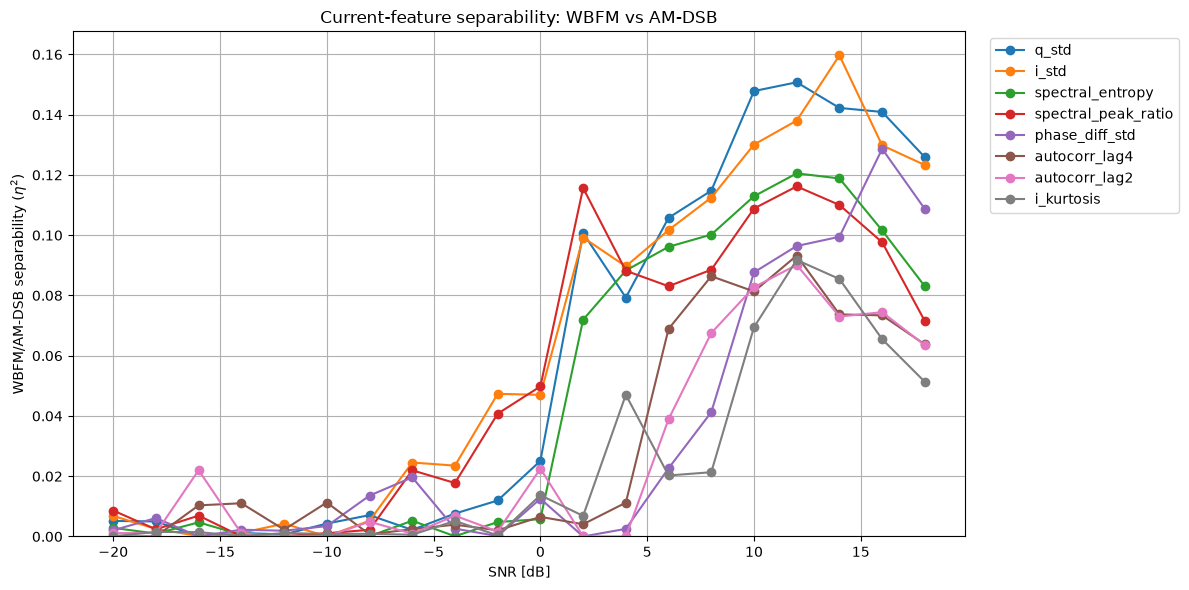

In [74]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for feature in top_analog_features:

    feature_data = (
        analog_pair_separability_df[
            analog_pair_separability_df[
                "feature"
            ]
            == feature
        ]
    )

    ax.plot(
        feature_data["snr"],
        feature_data["eta_squared"],
        marker="o",
        label=feature,
    )

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    r"WBFM/AM-DSB separability ($\eta^2$)"
)

ax.set_title(
    "Current-feature separability: WBFM vs AM-DSB"
)

ax.set_ylim(bottom=0)

ax.grid(True)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

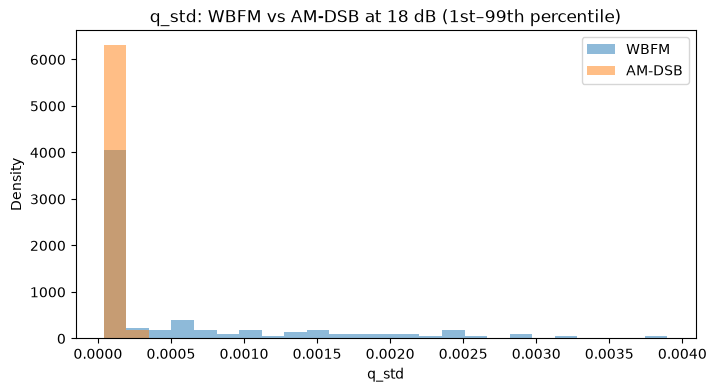

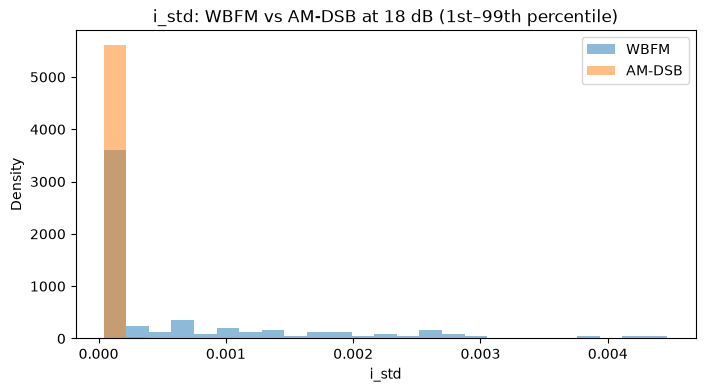

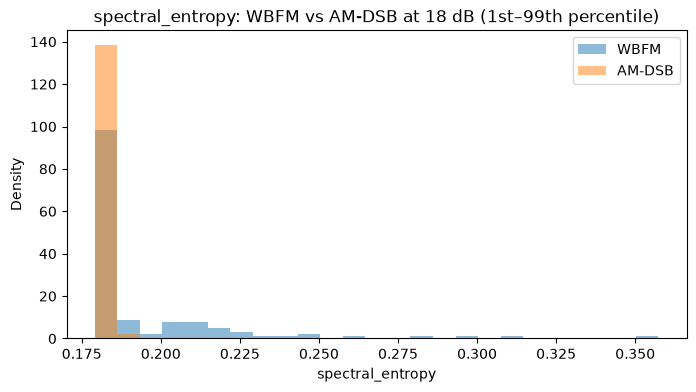

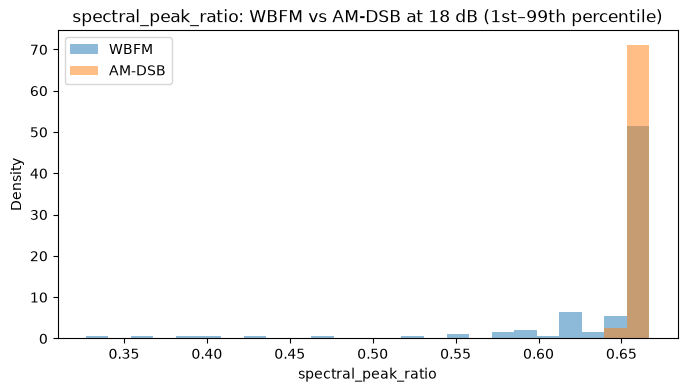

In [76]:
snr_to_plot = 18

for feature in analog_features_for_distribution:

    pair_values = validation_features_full[
        (
            validation_features_full["snr"]
            == snr_to_plot
        )
        &
        (
            validation_features_full[
                "modulation"
            ].isin(analog_pair)
        )
    ][feature]

    lower = pair_values.quantile(0.01)
    upper = pair_values.quantile(0.99)

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    for modulation in analog_pair:

        values = validation_features_full[
            (
                validation_features_full["snr"]
                == snr_to_plot
            )
            &
            (
                validation_features_full[
                    "modulation"
                ]
                == modulation
            )
        ][feature]

        ax.hist(
            values,
            bins=25,
            range=(lower, upper),
            density=True,
            alpha=0.5,
            label=modulation,
        )

    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    ax.set_title(
        f"{feature}: WBFM vs AM-DSB "
        f"at {snr_to_plot} dB "
        "(1st–99th percentile)"
    )

    ax.legend()

    plt.show()

### 11.5 Preliminary conclusions — WBFM vs AM-DSB

WBFM and AM-DSB exhibit greater pair-specific separability with the
current feature representation than the previously analysed PSK and QAM
pairs.

At 18 dB, several descriptors reach eta-squared values around 0.1,
including I/Q dispersion, phase-difference variability and spectral
flatness.

This indicates that the current representation already contains partial
information capable of distinguishing AM-DSB from WBFM.

The appearance of `phase_diff_std` among the strongest features is
physically consistent with FM carrying information through instantaneous
phase and frequency variations. Spectral entropy, flatness, bandwidth
and peak ratio also retain some discriminative information.

However, the strongest individual descriptors remain only moderately
separating, and substantial overlap is present between the two classes.

Furthermore, the high ranking of separate I and Q standard deviations
should be interpreted cautiously because these descriptors are sensitive
to rotations of the complex I/Q plane.

The current representation therefore captures part of the AM/FM
distinction but does not explicitly describe the temporal dynamics of
the signal envelope and instantaneous frequency. These properties remain
natural candidates for later feature engineering.

### 11.6 AM-DSB/WBFM decision asymmetry

The high-SNR confusion matrix is asymmetric.

AM-DSB is generally recognized correctly, whereas a substantial fraction
of WBFM samples are classified as AM-DSB.

The Random Forest probability outputs are therefore examined to determine
whether misclassified WBFM samples lie close to the AM-DSB/WBFM decision
boundary or whether the model strongly assigns them to AM-DSB.

In [77]:
am_dsb_index = np.where(
    model_classes == "AM-DSB"
)[0][0]

wbfm_index = np.where(
    model_classes == "WBFM"
)[0][0]

print(
    "AM-DSB probability index:",
    am_dsb_index
)

print(
    "WBFM probability index:",
    wbfm_index
)

AM-DSB probability index: 1
WBFM probability index: 10


In [78]:
evaluation_diagnostic_df[
    "prob_am_dsb"
] = validation_probabilities[
    :, am_dsb_index
]

evaluation_diagnostic_df[
    "prob_wbfm"
] = validation_probabilities[
    :, wbfm_index
]

evaluation_diagnostic_df[
    "analog_probability_difference"
] = (
    evaluation_diagnostic_df[
        "prob_am_dsb"
    ]
    -
    evaluation_diagnostic_df[
        "prob_wbfm"
    ]
)

In [79]:
analog_18 = (
    evaluation_diagnostic_df[
        (
            evaluation_diagnostic_df[
                "snr"
            ]
            == 18
        )
        &
        (
            evaluation_diagnostic_df[
                "true_modulation"
            ].isin(
                ["AM-DSB", "WBFM"]
            )
        )
    ]
    .copy()
)

analog_18.groupby(
    "true_modulation"
)[
    [
        "prob_am_dsb",
        "prob_wbfm",
        "analog_probability_difference",
        "max_probability",
        "top2_margin",
    ]
].agg(
    ["mean", "median", "std"]
).round(3)

prob_am_dsb               prob_wbfm                \
                       mean median    std      mean median    std   
true_modulation                                                     
AM-DSB                0.694  0.606  0.189     0.306  0.394  0.190   
WBFM                  0.319  0.455  0.255     0.669  0.545  0.244   

                analog_probability_difference               max_probability  \
                                         mean median    std            mean   
true_modulation                                                               
AM-DSB                                  0.388  0.213  0.379           0.702   
WBFM                                   -0.350 -0.090  0.496           0.717   

                              top2_margin                
                median    std        mean median    std  
true_modulation                                          
AM-DSB           0.607  0.181       0.404  0.214  0.361  
WBFM             0.596  0.202       0.434  0.192  0.405

In [80]:
wbfm_18 = (
    analog_18[
        analog_18[
            "true_modulation"
        ]
        == "WBFM"
    ]
    .copy()
)

wbfm_18[
    "wbfm_correct"
] = (
    wbfm_18[
        "predicted_modulation"
    ]
    == "WBFM"
)

wbfm_confidence_comparison = (
    wbfm_18
    .groupby("wbfm_correct")
    [
        [
            "prob_am_dsb",
            "prob_wbfm",
            "analog_probability_difference",
            "max_probability",
            "top2_margin",
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
)

wbfm_confidence_comparison.round(3)

prob_am_dsb               prob_wbfm                \
                    mean median    std      mean median    std   
wbfm_correct                                                     
False              0.566  0.558  0.050     0.434  0.442  0.050   
True               0.179  0.019  0.214     0.801  0.922  0.207   

             analog_probability_difference               max_probability  \
                                      mean median    std            mean   
wbfm_correct                                                               
False                                0.133  0.116  0.099           0.566   
True                                -0.622 -0.884  0.416           0.801   

                           top2_margin                
             median    std        mean median    std  
wbfm_correct                                          
False         0.558  0.050       0.133  0.116  0.099  
True          0.922  0.207       0.603  0.844  0.414

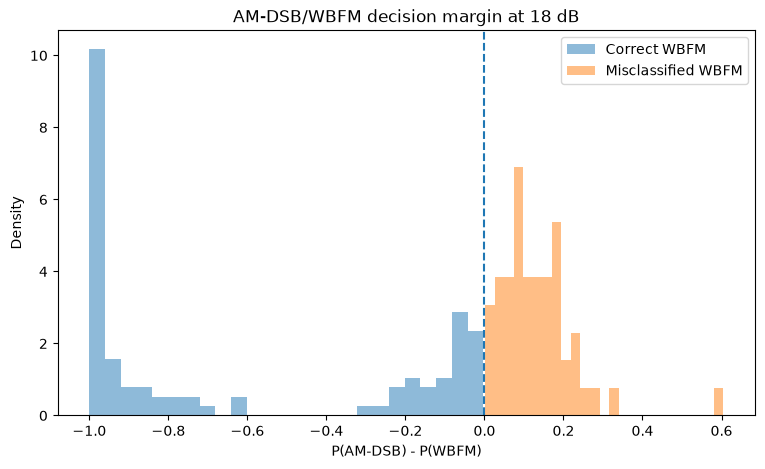

In [81]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for correct_value, label in [
    (True, "Correct WBFM"),
    (False, "Misclassified WBFM"),
]:

    values = wbfm_18[
        wbfm_18[
            "wbfm_correct"
        ]
        == correct_value
    ][
        "analog_probability_difference"
    ]

    ax.hist(
        values,
        bins=25,
        density=True,
        alpha=0.5,
        label=label,
    )

ax.axvline(
    0,
    linestyle="--"
)

ax.set_xlabel(
    "P(AM-DSB) - P(WBFM)"
)

ax.set_ylabel("Density")

ax.set_title(
    "AM-DSB/WBFM decision margin at 18 dB"
)

ax.legend()

plt.show()

In [82]:
wbfm_18[
    "predicted_modulation"
].value_counts(
    normalize=True
).round(3)

predicted_modulation
WBFM      0.64
AM-DSB    0.36
Name: proportion, dtype: float64

### 11.7 Conclusions — WBFM vs AM-DSB

The probability analysis confirms that the WBFM/AM-DSB confusion is
localized almost entirely within this modulation pair.

At 18 dB, true AM-DSB samples receive on average substantially greater
support for AM-DSB, whereas true WBFM samples receive greater support
for WBFM.

However, approximately 36% of WBFM samples are classified specifically
as AM-DSB.

The decision-margin distribution shows that correctly classified WBFM
samples and misclassified WBFM samples occupy noticeably different
regions of the classifier output space, rather than all samples lying
close to a single ambiguous boundary.

Therefore, the current feature representation contains meaningful
information for distinguishing the two analog modulations, but it does
not represent all WBFM realizations robustly.

This motivates later investigation of explicit envelope dynamics and
instantaneous-frequency dynamics, which correspond more directly to the
physical distinction between AM and FM.

---

# Part IV — Pairwise separability with the current representation

## 12. Binary classification experiments

The previous analyses evaluated individual feature separability on the
validation set.

However, weak individual features may still provide useful information
when combined nonlinearly by a classifier.

Three binary classification experiments are therefore performed using
the existing 28-feature representation:

1. QPSK vs 8PSK
2. QAM16 vs QAM64
3. WBFM vs AM-DSB

These experiments use only the training split.

Five-fold cross-validation is used to generate out-of-fold predictions,
and the folds are stratified jointly by modulation and SNR.

No hyperparameter tuning is performed.

The objective is diagnostic:

> Can the existing feature representation separate each problematic
> modulation pair when the classifier is dedicated exclusively to that
> decision?

In [83]:
train_features_full = pd.read_pickle(
    PROCESSED_DIR
    / "train_full_features.pkl"
)

print(
    "Training features:",
    train_features_full.shape
)

Training features: (154000, 31)


In [84]:
X_train_full = train_features_full[
    all_feature_columns
]

y_train_full = train_features_full[
    "modulation"
]

snr_train_full = train_features_full[
    "snr"
]

In [85]:
from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)

from sklearn.ensemble import (
    RandomForestClassifier,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)

In [86]:
def evaluate_binary_pair_cv(
    dataframe,
    class_a,
    class_b,
    feature_columns,
    n_splits=5,
):
    pair_df = dataframe[
        dataframe["modulation"].isin(
            [class_a, class_b]
        )
    ].copy()

    X_pair = pair_df[
        feature_columns
    ]

    y_pair = pair_df[
        "modulation"
    ]

    joint_strata = (
        pair_df["modulation"].astype(str)
        + "_"
        + pair_df["snr"].astype(str)
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    oof_predictions = cross_val_predict(
        model,
        X_pair,
        y_pair,
        cv=cv.split(
            X_pair,
            joint_strata,
        ),
        method="predict",
        n_jobs=1,
    )

    results = pair_df[
        [
            "modulation",
            "snr",
        ]
    ].copy()

    results[
        "prediction"
    ] = oof_predictions

    overall_accuracy = accuracy_score(
        y_pair,
        oof_predictions,
    )

    overall_f1 = f1_score(
        y_pair,
        oof_predictions,
        average="macro",
    )

    return {
        "classes": (
            class_a,
            class_b,
        ),
        "accuracy": overall_accuracy,
        "macro_f1": overall_f1,
        "results": results,
    }

In [87]:
binary_pairs = [
    ("QPSK", "8PSK"),
    ("QAM16", "QAM64"),
    ("WBFM", "AM-DSB"),
]

binary_results = {}

for class_a, class_b in binary_pairs:

    print(
        f"Running {class_a} vs {class_b}..."
    )

    result = evaluate_binary_pair_cv(
        train_features_full,
        class_a,
        class_b,
        all_feature_columns,
    )

    binary_results[
        (class_a, class_b)
    ] = result

    print(
        f"Accuracy: "
        f"{result['accuracy']:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{result['macro_f1']:.4f}"
    )

    print()

Running QPSK vs 8PSK...
Accuracy: 0.6377
Macro-F1: 0.6377

Running QAM16 vs QAM64...
Accuracy: 0.6164
Macro-F1: 0.6135

Running WBFM vs AM-DSB...
Accuracy: 0.6221
Macro-F1: 0.6186



In [88]:
binary_summary_rows = []

for pair, result in (
    binary_results.items()
):

    binary_summary_rows.append({
        "pair":
            f"{pair[0]} vs {pair[1]}",

        "accuracy":
            result["accuracy"],

        "macro_f1":
            result["macro_f1"],
    })

binary_summary = pd.DataFrame(
    binary_summary_rows
)

binary_summary.round(4)

,pair,accuracy,macro_f1
0,QPSK vs 8PSK,0.6377,0.6377
1,QAM16 vs QAM64,0.6164,0.6135
2,WBFM vs AM-DSB,0.6221,0.6186


In [89]:
binary_snr_rows = []

for pair, result in (
    binary_results.items()
):

    pair_name = (
        f"{pair[0]} vs {pair[1]}"
    )

    result_df = result[
        "results"
    ]

    for snr, group in (
        result_df.groupby("snr")
    ):

        accuracy = accuracy_score(
            group["modulation"],
            group["prediction"],
        )

        binary_snr_rows.append({
            "pair": pair_name,
            "snr": snr,
            "accuracy": accuracy,
        })

binary_accuracy_by_snr = (
    pd.DataFrame(
        binary_snr_rows
    )
)

binary_accuracy_by_snr.pivot(
    index="snr",
    columns="pair",
    values="accuracy",
).round(3)

pair,QAM16 vs QAM64,QPSK vs 8PSK,WBFM vs AM-DSB
snr,,,
-20,0.499,0.506,0.509
-18,0.511,0.490,0.511
-16,0.561,0.490,0.499
-14,0.636,0.510,0.486
-12,0.646,0.488,0.541
-10,0.510,0.511,0.548
-8,0.512,0.503,0.523
-6,0.601,0.501,0.534
-4,0.563,0.489,0.559


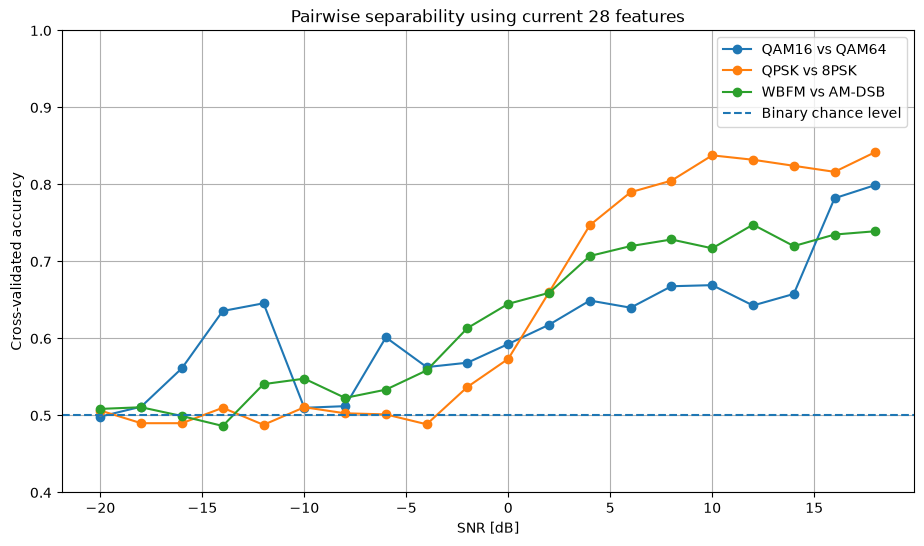

In [90]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for pair_name, group in (
    binary_accuracy_by_snr.groupby(
        "pair"
    )
):

    ax.plot(
        group["snr"],
        group["accuracy"],
        marker="o",
        label=pair_name,
    )

ax.axhline(
    0.5,
    linestyle="--",
    label="Binary chance level",
)

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    "Cross-validated accuracy"
)

ax.set_title(
    "Pairwise separability using current 28 features"
)

ax.set_ylim(
    0.4,
    1.0,
)

ax.grid(True)

ax.legend()

plt.show()

### 12.8 Conclusions — Pairwise classification

The binary cross-validation experiments demonstrate that the current
28-feature representation contains substantially more pair-specific
information jointly than suggested by individual-feature effect sizes.

At high SNR:

- QPSK vs 8PSK reaches approximately 84% accuracy;
- QAM16 vs QAM64 reaches approximately 80%;
- WBFM vs AM-DSB reaches approximately 74%.

Therefore, the persistent multiclass confusions cannot be attributed
exclusively to a complete absence of information in the current feature
representation.

Instead, weak information distributed across several descriptors can be
combined by a dedicated nonlinear classifier.

QPSK/8PSK shows particularly strong conditional separability at high SNR,
making a PSK specialist potentially useful. QAM16/QAM64 also contains
meaningful multivariate information, although its unusual non-monotonic
behaviour across SNR requires caution. WBFM/AM-DSB remains the least
separable high-SNR pair among the three specialists.

However, these binary results assume oracle knowledge that each sample
belongs to the corresponding pair. They therefore represent conditional
separability rather than end-to-end hierarchical performance.

A practical mixture-of-experts architecture would additionally require a
reliable routing mechanism. The next experiment evaluates whether the
global classifier can identify the appropriate difficult pair before a
specialist is invoked.

## 13. Routing feasibility for selective specialists

The previous binary experiments assume that the correct modulation pair
is known in advance.

A practical specialist architecture requires a routing mechanism.

A conservative routing strategy is investigated using the two highest
probability classes produced by the global Random Forest.

A pair specialist would only be activated when the two most likely
classes correspond exactly to one of the predefined difficult pairs.

For each pair, two quantities are of interest:

- **coverage**: fraction of true pair samples for which the corresponding
  specialist would be activated;
- **purity**: fraction of specialist activations that actually correspond
  to samples belonging to that pair.

High coverage with low purity would be dangerous because unrelated
modulations would be sent to the specialist.

High purity with reasonable coverage would support a selective
mixture-of-experts architecture.

This analysis is diagnostic only; no routing threshold is tuned here.

In [91]:
sorted_class_indices = np.argsort(
    validation_probabilities,
    axis=1,
)

top1_indices = (
    sorted_class_indices[:, -1]
)

top2_indices = (
    sorted_class_indices[:, -2]
)

evaluation_diagnostic_df[
    "top1_class"
] = model_classes[
    top1_indices
]

evaluation_diagnostic_df[
    "top2_class"
] = model_classes[
    top2_indices
]

In [92]:
print(
    (
        evaluation_diagnostic_df[
            "top1_class"
        ]
        ==
        evaluation_diagnostic_df[
            "predicted_modulation"
        ]
    ).mean()
)

1.0


In [93]:
difficult_pairs = [
    ("QPSK", "8PSK"),
    ("QAM16", "QAM64"),
    ("WBFM", "AM-DSB"),
]


def evaluate_pair_routing(
    dataframe,
    class_a,
    class_b,
):
    pair_name = (
        f"{class_a} vs {class_b}"
    )

    true_in_pair = (
        dataframe[
            "true_modulation"
        ].isin(
            [class_a, class_b]
        )
    )

    pair_is_top2 = (
        (
            (
                dataframe["top1_class"]
                == class_a
            )
            &
            (
                dataframe["top2_class"]
                == class_b
            )
        )
        |
        (
            (
                dataframe["top1_class"]
                == class_b
            )
            &
            (
                dataframe["top2_class"]
                == class_a
            )
        )
    )

    rows = []

    for snr in sorted(
        dataframe["snr"].unique()
    ):

        snr_mask = (
            dataframe["snr"] == snr
        )

        true_pair_at_snr = (
            true_in_pair
            & snr_mask
        )

        trigger_at_snr = (
            pair_is_top2
            & snr_mask
        )

        coverage = (
            pair_is_top2[
                true_pair_at_snr
            ].mean()
        )

        if trigger_at_snr.sum() > 0:
            purity = (
                true_in_pair[
                    trigger_at_snr
                ].mean()
            )
        else:
            purity = np.nan

        rows.append({
            "pair": pair_name,
            "snr": snr,
            "coverage": coverage,
            "purity": purity,
            "n_triggers":
                trigger_at_snr.sum(),
        })

    return pd.DataFrame(rows)

In [94]:
routing_results = []

for class_a, class_b in (
    difficult_pairs
):

    pair_routing = (
        evaluate_pair_routing(
            evaluation_diagnostic_df,
            class_a,
            class_b,
        )
    )

    routing_results.append(
        pair_routing
    )

routing_df = pd.concat(
    routing_results,
    ignore_index=True,
)

In [95]:
routing_coverage_table = (
    routing_df
    .pivot(
        index="snr",
        columns="pair",
        values="coverage",
    )
)

routing_coverage_table.round(3)

pair,QAM16 vs QAM64,QPSK vs 8PSK,WBFM vs AM-DSB
snr,,,
-20,0.000,0.010,0.033
-18,0.000,0.000,0.030
-16,0.000,0.003,0.097
-14,0.027,0.000,0.083
-12,0.103,0.000,0.287
-10,0.323,0.007,0.533
-8,0.547,0.020,0.793
-6,0.777,0.070,0.857
-4,0.803,0.143,0.917


In [96]:
routing_purity_table = (
    routing_df
    .pivot(
        index="snr",
        columns="pair",
        values="purity",
    )
)

routing_purity_table.round(3)

pair,QAM16 vs QAM64,QPSK vs 8PSK,WBFM vs AM-DSB
snr,,,
-20,NaN,0.500,0.238
-18,NaN,0.000,0.205
-16,NaN,0.125,0.630
-14,1.000,0.000,0.455
-12,0.939,0.000,0.677
-10,0.990,0.049,0.796
-8,0.948,0.092,0.841
-6,0.883,0.304,0.865
-4,0.772,0.434,0.945


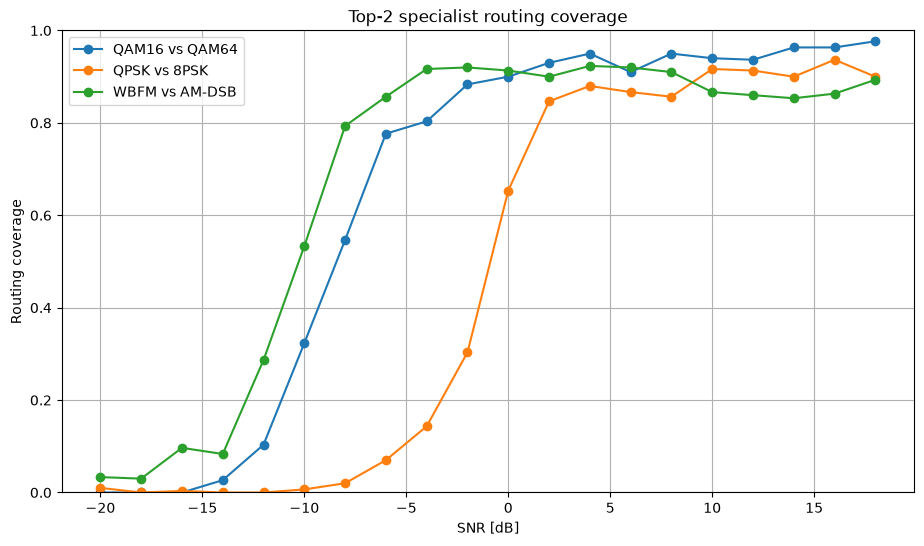

In [97]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for pair_name, group in (
    routing_df.groupby("pair")
):

    ax.plot(
        group["snr"],
        group["coverage"],
        marker="o",
        label=pair_name,
    )

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Routing coverage")

ax.set_title(
    "Top-2 specialist routing coverage"
)

ax.set_ylim(0, 1)

ax.grid(True)
ax.legend()

plt.show()

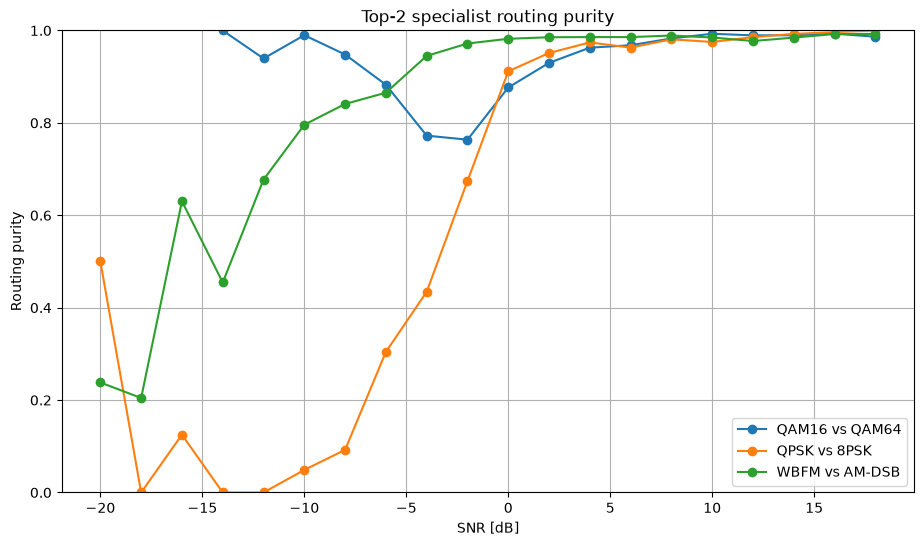

In [98]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for pair_name, group in (
    routing_df.groupby("pair")
):

    ax.plot(
        group["snr"],
        group["purity"],
        marker="o",
        label=pair_name,
    )

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Routing purity")

ax.set_title(
    "Top-2 specialist routing purity"
)

ax.set_ylim(0, 1)

ax.grid(True)
ax.legend()

plt.show()

### 13.6 Conclusions — Specialist routing feasibility

The top-2 probability structure of the global Random Forest provides a
high-quality routing signal at moderate and high SNR.

At 18 dB:

- QAM16/QAM64 routing reaches approximately 97.7% coverage and 98.7% purity;
- QPSK/8PSK reaches approximately 90.0% coverage and 100% purity;
- WBFM/AM-DSB reaches approximately 89.3% coverage and 99.3% purity.

Therefore, when the global classifier identifies one of the difficult
pairs among its two most probable classes, the corresponding pair is
almost always correct at high SNR.

This supports a selective mixture-of-experts architecture rather than a
hard hierarchical family classifier.

Under the selective strategy, the global Random Forest would remain the
default classifier and a specialist would only be invoked when its two
classes form the global top-2 predictions.

Routing performance deteriorates strongly at very low SNR, particularly
for the PSK pair. Purity values in this regime should also be interpreted
cautiously because very few specialist activations occur.

These results establish that routing is feasible, but they do not yet
demonstrate that specialist predictions improve over the global model on
the routed samples. This must be evaluated directly before adopting the
architecture.

---

# Part V — End-to-end selective specialists

## 14. Selective mixture-of-experts using train-only OOF predictions

Routing feasibility was previously analysed using the fixed global
Random Forest.

The next objective is to determine whether replacing the global decision
with a pair-specific specialist actually improves classification.

To avoid further tuning against the validation set, this experiment is
performed entirely within the training split using out-of-fold
predictions.

For every training sample:

1. an out-of-fold global Random Forest produces the original multiclass
   prediction and class probabilities;
2. the global top-2 classes determine whether a specialist is eligible;
3. an out-of-fold binary specialist produces a prediction for its
   corresponding pair;
4. the specialist prediction replaces the global prediction only when
   the fixed top-2 routing rule is satisfied.

This provides an unbiased train-only estimate of the end-to-end
mixture-of-experts behaviour.

In [99]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

global_joint_strata = (
    train_features_full["modulation"].astype(str)
    + "_"
    + train_features_full["snr"].astype(str)
)

global_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

global_oof_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

global_oof_probabilities = cross_val_predict(
    global_oof_model,
    X_train_full,
    y_train_full,
    cv=global_cv.split(
        X_train_full,
        global_joint_strata,
    ),
    method="predict_proba",
    n_jobs=1,
)

In [100]:
global_classes = np.sort(
    y_train_full.unique()
)

print(
    global_oof_probabilities.shape
)

print(
    global_classes
)

(154000, 11)
['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


In [101]:
print(
    np.array_equal(
        global_classes,
        final_candidate_rf.classes_,
    )
)

True


In [102]:
global_top1_indices = np.argmax(
    global_oof_probabilities,
    axis=1,
)

global_oof_predictions = (
    global_classes[
        global_top1_indices
    ]
)

global_oof_accuracy = accuracy_score(
    y_train_full,
    global_oof_predictions,
)

global_oof_f1 = f1_score(
    y_train_full,
    global_oof_predictions,
    average="macro",
)

print(
    f"Global OOF accuracy: "
    f"{global_oof_accuracy:.4f}"
)

print(
    f"Global OOF macro-F1: "
    f"{global_oof_f1:.4f}"
)

Global OOF accuracy: 0.5331
Global OOF macro-F1: 0.5510


In [103]:
global_sorted_indices = np.argsort(
    global_oof_probabilities,
    axis=1,
)

global_top1_classes = (
    global_classes[
        global_sorted_indices[:, -1]
    ]
)

global_top2_classes = (
    global_classes[
        global_sorted_indices[:, -2]
    ]
)

In [104]:
def evaluate_binary_pair_cv_with_index(
    dataframe,
    class_a,
    class_b,
    feature_columns,
    n_splits=5,
):
    pair_df = dataframe[
        dataframe["modulation"].isin(
            [class_a, class_b]
        )
    ].copy()

    X_pair = pair_df[
        feature_columns
    ]

    y_pair = pair_df[
        "modulation"
    ]

    joint_strata = (
        pair_df["modulation"].astype(str)
        + "_"
        + pair_df["snr"].astype(str)
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    predictions = cross_val_predict(
        model,
        X_pair,
        y_pair,
        cv=cv.split(
            X_pair,
            joint_strata,
        ),
        method="predict",
        n_jobs=1,
    )

    results = pair_df[
        [
            "modulation",
            "snr",
        ]
    ].copy()

    results["prediction"] = predictions

    return results

In [105]:
specialist_oof_results = {}

for class_a, class_b in difficult_pairs:

    print(
        f"Generating OOF specialist: "
        f"{class_a} vs {class_b}"
    )

    specialist_oof_results[
        (class_a, class_b)
    ] = (
        evaluate_binary_pair_cv_with_index(
            train_features_full,
            class_a,
            class_b,
            all_feature_columns,
        )
    )

Generating OOF specialist: QPSK vs 8PSK
Generating OOF specialist: QAM16 vs QAM64
Generating OOF specialist: WBFM vs AM-DSB


### 14.4 Aligned out-of-fold specialist predictions

The previous binary specialist predictions were generated only for samples
that genuinely belonged to each modulation pair.

That is sufficient for measuring conditional pairwise separability, but
not for evaluating a complete mixture-of-experts system.

In practice, the router can occasionally activate a specialist for a
sample that does not belong to its pair. The specialist would still be
forced to output one of its two classes.

Therefore, a new aligned out-of-fold experiment is constructed.

For each global cross-validation fold:

1. the global classifier is trained on the training portion;
2. each specialist is trained using only its corresponding pair within
   the same training portion;
3. the global classifier and all specialists predict every sample in the
   held-out fold.

This allows routing errors and specialist errors to be evaluated jointly
without training any model on the sample being predicted.

In [106]:
global_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cv_splits = list(
    global_cv.split(
        X_train_full,
        global_joint_strata,
    )
)

print(
    "Number of folds:",
    len(cv_splits)
)

Number of folds: 5


In [107]:
n_samples = len(train_features_full)

aligned_global_predictions = np.empty(
    n_samples,
    dtype=object,
)

aligned_global_probabilities = np.zeros(
    (
        n_samples,
        len(global_classes),
    )
)

aligned_specialist_predictions = {
    pair: np.empty(
        n_samples,
        dtype=object,
    )
    for pair in difficult_pairs
}

In [108]:
for fold_number, (
    train_idx,
    val_idx,
) in enumerate(
    cv_splits,
    start=1,
):

    print(
        f"Running fold {fold_number}/5..."
    )

    # --------------------------------
    # Global model
    # --------------------------------

    global_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    global_model.fit(
        X_train_full.iloc[train_idx],
        y_train_full.iloc[train_idx],
    )

    fold_probabilities = (
        global_model.predict_proba(
            X_train_full.iloc[val_idx]
        )
    )

    aligned_global_probabilities[
        val_idx
    ] = fold_probabilities

    aligned_global_predictions[
        val_idx
    ] = global_model.predict(
        X_train_full.iloc[val_idx]
    )

    # --------------------------------
    # Pair specialists
    # --------------------------------

    fold_train_df = (
        train_features_full.iloc[
            train_idx
        ]
    )

    for class_a, class_b in (
        difficult_pairs
    ):

        specialist_train = (
            fold_train_df[
                fold_train_df[
                    "modulation"
                ].isin(
                    [class_a, class_b]
                )
            ]
        )

        specialist_model = (
            RandomForestClassifier(
                n_estimators=200,
                max_depth=20,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            )
        )

        specialist_model.fit(
            specialist_train[
                all_feature_columns
            ],
            specialist_train[
                "modulation"
            ],
        )

        # Important:
        # predict the ENTIRE held-out fold,
        # not only true pair samples.
        aligned_specialist_predictions[
            (class_a, class_b)
        ][val_idx] = (
            specialist_model.predict(
                X_train_full.iloc[
                    val_idx
                ]
            )
        )

Running fold 1/5...
Running fold 2/5...
Running fold 3/5...
Running fold 4/5...
Running fold 5/5...


In [109]:
aligned_global_accuracy = (
    accuracy_score(
        y_train_full,
        aligned_global_predictions,
    )
)

aligned_global_f1 = f1_score(
    y_train_full,
    aligned_global_predictions,
    average="macro",
)

print(
    f"Aligned global OOF accuracy: "
    f"{aligned_global_accuracy:.4f}"
)

print(
    f"Aligned global OOF macro-F1: "
    f"{aligned_global_f1:.4f}"
)

Aligned global OOF accuracy: 0.5331
Aligned global OOF macro-F1: 0.5510


In [110]:
aligned_sorted_indices = np.argsort(
    aligned_global_probabilities,
    axis=1,
)

aligned_top1 = global_classes[
    aligned_sorted_indices[:, -1]
]

aligned_top2 = global_classes[
    aligned_sorted_indices[:, -2]
]

In [111]:
print(
    np.mean(
        aligned_top1
        == aligned_global_predictions
    )
)

1.0


In [112]:
moe_predictions = (
    aligned_global_predictions.copy()
)

In [113]:
routing_masks = {}

for class_a, class_b in difficult_pairs:

    route_mask = (
        (
            (aligned_top1 == class_a)
            &
            (aligned_top2 == class_b)
        )
        |
        (
            (aligned_top1 == class_b)
            &
            (aligned_top2 == class_a)
        )
    )

    routing_masks[
        (class_a, class_b)
    ] = route_mask

    moe_predictions[
        route_mask
    ] = (
        aligned_specialist_predictions[
            (class_a, class_b)
        ][route_mask]
    )

    print(
        f"{class_a} vs {class_b}: "
        f"{route_mask.sum()} routed samples"
    )

QPSK vs 8PSK: 14410 routed samples
QAM16 vs QAM64: 19501 routed samples
WBFM vs AM-DSB: 20265 routed samples


In [114]:
moe_accuracy = accuracy_score(
    y_train_full,
    moe_predictions,
)

moe_f1 = f1_score(
    y_train_full,
    moe_predictions,
    average="macro",
)

print(
    "GLOBAL RF"
)

print(
    f"Accuracy: "
    f"{aligned_global_accuracy:.4f}"
)

print(
    f"Macro-F1: "
    f"{aligned_global_f1:.4f}"
)

print()

print(
    "SELECTIVE MoE"
)

print(
    f"Accuracy: "
    f"{moe_accuracy:.4f}"
)

print(
    f"Macro-F1: "
    f"{moe_f1:.4f}"
)

print()

print(
    "Improvement"
)

print(
    f"Accuracy: "
    f"{moe_accuracy - aligned_global_accuracy:+.4f}"
)

print(
    f"Macro-F1: "
    f"{moe_f1 - aligned_global_f1:+.4f}"
)

GLOBAL RF
Accuracy: 0.5331
Macro-F1: 0.5510

SELECTIVE MoE
Accuracy: 0.5338
Macro-F1: 0.5521

Improvement
Accuracy: +0.0007
Macro-F1: +0.0011


In [115]:
comparison_df = pd.DataFrame({
    "true_modulation":
        y_train_full.to_numpy(),

    "snr":
        snr_train_full.to_numpy(),

    "global_prediction":
        aligned_global_predictions,

    "moe_prediction":
        moe_predictions,
})

In [116]:
comparison_df[
    "global_correct"
] = (
    comparison_df[
        "true_modulation"
    ]
    ==
    comparison_df[
        "global_prediction"
    ]
)

comparison_df[
    "moe_correct"
] = (
    comparison_df[
        "true_modulation"
    ]
    ==
    comparison_df[
        "moe_prediction"
    ]
)

In [117]:
errors_corrected = (
    (~comparison_df["global_correct"])
    &
    (comparison_df["moe_correct"])
).sum()

errors_introduced = (
    (comparison_df["global_correct"])
    &
    (~comparison_df["moe_correct"])
).sum()

print(
    "Errors corrected:",
    errors_corrected
)

print(
    "Errors introduced:",
    errors_introduced
)

print(
    "Net corrections:",
    errors_corrected
    - errors_introduced
)

Errors corrected: 3275
Errors introduced: 3164
Net corrections: 111


In [118]:
specialist_effect_rows = []

for pair, route_mask in (
    routing_masks.items()
):

    pair_name = (
        f"{pair[0]} vs {pair[1]}"
    )

    global_correct_pair = (
        comparison_df.loc[
            route_mask,
            "global_correct",
        ].to_numpy()
    )

    moe_correct_pair = (
        comparison_df.loc[
            route_mask,
            "moe_correct",
        ].to_numpy()
    )

    corrected = np.sum(
        (~global_correct_pair)
        &
        moe_correct_pair
    )

    introduced = np.sum(
        global_correct_pair
        &
        (~moe_correct_pair)
    )

    specialist_effect_rows.append({
        "pair": pair_name,
        "n_routed":
            route_mask.sum(),

        "corrected_errors":
            corrected,

        "introduced_errors":
            introduced,

        "net_corrections":
            corrected
            - introduced,
    })

specialist_effect_df = pd.DataFrame(
    specialist_effect_rows
)

specialist_effect_df

,pair,n_routed,corrected_errors,introduced_errors,net_corrections
0,QPSK vs 8PSK,14410,710,631,79
1,QAM16 vs QAM64,19501,1025,1014,11
2,WBFM vs AM-DSB,20265,1540,1519,21


### 14.13 Conclusions — End-to-end mixture of experts

The end-to-end out-of-fold experiment shows that the selective
mixture-of-experts architecture provides only a negligible improvement
with the current 28-feature representation.

The global Random Forest obtains:

- Accuracy = 0.5331
- Macro-F1 = 0.5510

The selective mixture-of-experts obtains:

- Accuracy = 0.5338
- Macro-F1 = 0.5521

This corresponds to improvements of only approximately 0.07 percentage
points in accuracy and 0.11 percentage points in macro-F1.

Although the specialists correct 3275 errors, they also introduce 3164
new errors, resulting in only 111 net corrections over 154,000
out-of-fold training predictions.

The PSK specialist provides the largest positive contribution, but even
its net effect remains small. The QAM and analog specialists almost
exactly exchange corrected errors for newly introduced errors.

Therefore, the current evidence does not justify adopting a
mixture-of-experts architecture. The global classifier already exploits
most of the multivariate information available in the existing feature
representation.

Specialization may become useful after introducing more physically
targeted pair-specific features, but with the current representation its
additional complexity is not warranted.

## 15. SNR dependence of specialist gains

Although the overall selective mixture-of-experts improvement is
negligible, routing quality was previously observed to increase strongly
with SNR.

This section determines whether specialist models provide meaningful
gains specifically in the medium- or high-SNR regimes.

The true SNR is used only as an oracle diagnostic variable and is not
provided to either the classifier or the routing mechanism.

In [119]:
snr_comparison_rows = []

for snr, group in comparison_df.groupby("snr"):

    global_accuracy = accuracy_score(
        group["true_modulation"],
        group["global_prediction"],
    )

    moe_accuracy = accuracy_score(
        group["true_modulation"],
        group["moe_prediction"],
    )

    snr_comparison_rows.append({
        "snr": snr,
        "global_accuracy": global_accuracy,
        "moe_accuracy": moe_accuracy,
        "difference": (
            moe_accuracy - global_accuracy
        ),
    })

moe_by_snr = pd.DataFrame(
    snr_comparison_rows
)

moe_by_snr.round(4)

,snr,global_accuracy,moe_accuracy,difference
0,-20,0.0947,0.0949,0.0003
1,-18,0.0956,0.0948,-0.0008
2,-16,0.0986,0.0990,0.0004
3,-14,0.1143,0.1151,0.0008
4,-12,0.1413,0.1455,0.0042
5,-10,0.2075,0.2078,0.0003
6,-8,0.3086,0.3047,-0.0039
7,-6,0.4243,0.4171,-0.0071
8,-4,0.4970,0.5019,0.0049
9,-2,0.5942,0.5938,-0.0004


In [120]:
snr_error_rows = []

for snr, group in comparison_df.groupby("snr"):

    corrected = (
        (~group["global_correct"])
        &
        group["moe_correct"]
    ).sum()

    introduced = (
        group["global_correct"]
        &
        (~group["moe_correct"])
    ).sum()

    snr_error_rows.append({
        "snr": snr,
        "corrected_errors": corrected,
        "introduced_errors": introduced,
        "net_corrections": (
            corrected - introduced
        ),
    })

moe_errors_by_snr = pd.DataFrame(
    snr_error_rows
)

moe_errors_by_snr

,snr,corrected_errors,introduced_errors,net_corrections
0,-20,10,8,2
1,-18,3,9,-6
2,-16,21,18,3
3,-14,43,37,6
4,-12,107,75,32
5,-10,185,183,2
6,-8,283,313,-30
7,-6,286,341,-55
8,-4,307,269,38
9,-2,266,269,-3


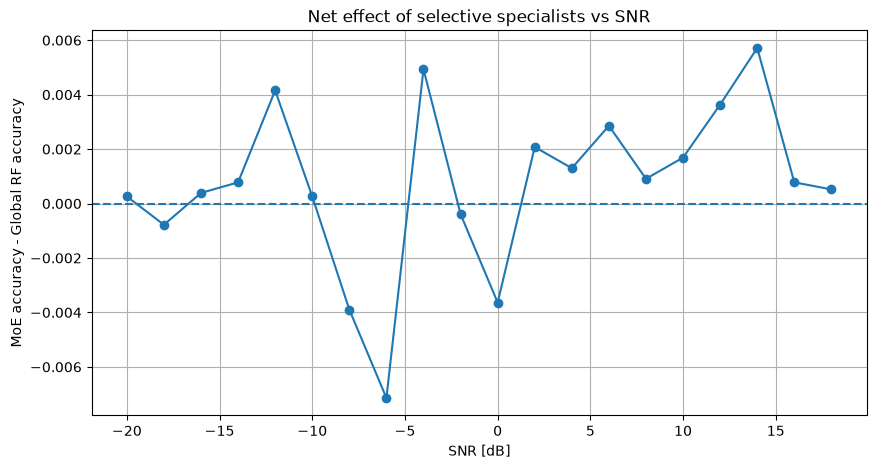

In [121]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    moe_by_snr["snr"],
    moe_by_snr["difference"],
    marker="o",
)

ax.axhline(
    0,
    linestyle="--",
)

ax.set_xlabel("SNR [dB]")

ax.set_ylabel(
    "MoE accuracy - Global RF accuracy"
)

ax.set_title(
    "Net effect of selective specialists vs SNR"
)

ax.grid(True)

plt.show()

### 15.2 Final conclusion on selective specialists

The SNR-dependent analysis does not reveal a hidden regime in which the
selective mixture-of-experts provides a substantial and consistent gain.

The largest observed accuracy improvement is approximately 0.57 percentage
points at 14 dB, while several medium- and low-SNR conditions are degraded
by the specialist architecture.

At 18 dB, despite extremely high routing purity, the improvement is only
approximately 0.05 percentage points.

Therefore, the negligible global improvement of the mixture-of-experts is
not simply caused by low-SNR samples masking large high-SNR gains.

With the current 28-feature representation, selective specialization does
not justify its additional architectural complexity.

The mixture-of-experts hypothesis is therefore rejected for the current
feature set. Future improvements should focus primarily on physically
motivated signal representation rather than additional classifier
complexity.